In [1]:
# basics libraries
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters

# Libraries for maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Units libraries
import metpy.calc as mpcalc
from metpy.units import units

# Time libraries
import matplotlib.dates as mdates

# plots libraries
import matplotlib.colors as mcolors
import os

# for altimeter analysis
from scipy.spatial import cKDTree

Dataset used for latitude, longitude definition

In [5]:
ds_0 = xr.open_dataset("C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Maps_diff//hs_mean_diff01.nc", engine="h5netcdf")
ds_0

<xarray.Dataset> Size: 16MB
Dimensions:    (time: 1, bnds: 2, latitude: 787, longitude: 1651)
Coordinates:
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
  * time       (time) datetime64[ns] 8B 2020-01-16T11:30:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 16B ...
    diff       (time, latitude, longitude) float32 5MB ...
Attributes: (12/22)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    product_name:                     ww3.run_with_currents202001.nc
    ...                               ...
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...
    history:                          Thu Oct  9 13:26:05 2025: ncks -A lan_l...
    history_of_appended_files:        Thu Oct  9 13:26:05 2025: Appended file...
    NCO:                              "4.5.2"

Define datasets

In [2]:
# With currents 
ds_model_01 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_01.nc", engine="h5netcdf") 
ds_model_02 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_02.nc", engine="h5netcdf")
ds_model_03 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_03.nc", engine="h5netcdf")
ds_model_04 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_04.nc", engine="h5netcdf")
ds_model_05 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_05.nc", engine="h5netcdf")
ds_model_06 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_06.nc", engine="h5netcdf")
ds_model_07 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_07.nc", engine="h5netcdf")
ds_model_08 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_08.nc", engine="h5netcdf")
ds_model_09 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_09.nc", engine="h5netcdf")
ds_model_10 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_10.nc", engine="h5netcdf")
ds_model_11 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_11.nc", engine="h5netcdf")
ds_model_12 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_12.nc", engine="h5netcdf")
ds_model_01

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 372, latitude: 787, longitude: 1651)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-01T04:00:00 ... 2020-01-31T20:...
Dimensions without coordinates: latitude, longitude
Data variables:
    hs       (time, latitude, longitude) float32 2GB ...
Attributes: (12/20)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    history:                          Mon Nov 24 12:25:13 2025: cdo -seltime,...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    minimum_altitude:                 -12000 m
    maximum_altitude:                 9000 m
    altitude_resolution:              n/a
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...

In [3]:
# no currents 
ds_model_01 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//no_cur//hs_no_cur_01.nc", engine="h5netcdf") 
ds_model_02 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//no_cur//hs_no_cur_02.nc", engine="h5netcdf")
ds_model_03 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//no_cur//hs_no_cur_03.nc", engine="h5netcdf")
ds_model_04 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//no_cur//hs_no_cur_04.nc", engine="h5netcdf")
ds_model_05 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//no_cur//hs_no_cur_05.nc", engine="h5netcdf")
ds_model_06 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//no_cur//hs_no_cur_06.nc", engine="h5netcdf")
ds_model_07 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//no_cur//hs_no_cur_07.nc", engine="h5netcdf")
ds_model_08 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//no_cur//hs_no_cur_08.nc", engine="h5netcdf")
ds_model_09 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//no_cur//hs_no_cur_09.nc", engine="h5netcdf")
ds_model_10 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//no_cur//hs_no_cur_10.nc", engine="h5netcdf")
ds_model_11 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//no_cur//hs_no_cur_11.nc", engine="h5netcdf")
ds_model_12 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//no_cur//hs_no_cur_12.nc", engine="h5netcdf")
ds_model_01

<xarray.Dataset> Size: 4GB
Dimensions:  (time: 744, y: 787, x: 1651)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
Dimensions without coordinates: y, x
Data variables:
    hs       (time, y, x) float32 4GB ...
Attributes: (12/22)
    CDI:                              Climate Data Interface version ?? (http...
    Conventions:                      CF-1.4
    history:                          Sat Nov 15 18:23:15 2025: cdo select,na...
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    altitude_resolution:              n/a
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    history_of_appended_files:        Thu Oct 30 10:37:20 2025: Appended file...
    NCO:                              "4.5.2"
    CDO:                              Climate Data Operators version 1.7.0 (h...

Assing coordinates to the data

In [6]:
ds_model_01 = ds_model_01.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_02 = ds_model_02.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_03 = ds_model_03.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_04 = ds_model_04.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_05 = ds_model_05.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_06 = ds_model_06.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_07 = ds_model_07.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_08 = ds_model_08.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_09 = ds_model_09.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_10 = ds_model_10.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_11 = ds_model_11.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_12 = ds_model_12.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_10

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 372, latitude: 787, longitude: 1651)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2020-10-01T04:00:00 ... 2020-10-31T2...
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
Data variables:
    hs         (time, latitude, longitude) float32 2GB ...
Attributes: (12/20)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    history:                          Tue Nov 25 08:58:16 2025: cdo -seltime,...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    minimum_altitude:                 -12000 m
    maximum_altitude:                 9000 m
    altitude_resolution:              n/a
    start_date:                       2020-10-01 00:00:00
    stop_date:                        2020-10-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...

Altimeter dataset

In [3]:
csv_file = "c://Users//kosta//OneDrive//Desktop//Διπλωματική//Data//Altimeter_data.csv"

# 1. Read the CSV into a pandas DataFrame
df_altim = pd.read_csv(csv_file)
print("Pandas DataFrame:")
df_altim

Pandas DataFrame:


,variable,platform_id,platform_type,time,longitude,latitude,depth,pressure,is_depth_from_producer,value,value_qc,institution,doi,product_doi
0,VAVH,CFOSAT,SAT,2020-01-01T05:39:07Z,30.464996,45.655,-0.0,NaN,1,1.299,1,CLS,NaN,https://doi.org/10.48670/moi-00176
1,VAVH,CFOSAT,SAT,2020-01-01T05:39:09Z,30.424988,45.536,-0.0,NaN,1,1.327,1,CLS,NaN,https://doi.org/10.48670/moi-00176
2,VAVH,CFOSAT,SAT,2020-01-01T05:39:10Z,30.403015,45.471,-0.0,NaN,1,1.394,1,CLS,NaN,https://doi.org/10.48670/moi-00176
3,VAVH,CFOSAT,SAT,2020-01-01T05:39:11Z,30.381012,45.405,-0.0,NaN,1,1.473,1,CLS,NaN,https://doi.org/10.48670/moi-00176
4,VAVH,CFOSAT,SAT,2020-01-01T05:39:13Z,30.342010,45.286,-0.0,NaN,1,1.547,1,CLS,NaN,https://doi.org/10.48670/moi-00176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112236,VAVH,CFOSAT,SAT,2020-12-31T07:02:22Z,7.803985,37.284,-0.0,NaN,1,2.032,1,CLS,NaN,https://doi.org/10.48670/moi-00176
112237,VAVH,CFOSAT,SAT,2020-12-31T07:02:23Z,7.786011,37.218,-0.0,NaN,1,1.918,1,CLS,NaN,https://doi.org/10.48670/moi-00176
112238,VAVH,CFOSAT,SAT,2020-12-31T07:02:24Z,7.768005,37.152,-0.0,NaN,1,1.825,1,CLS,NaN,https://doi.org/10.48670/moi-00176
112239,VAVH,CFOSAT,SAT,2020-12-31T07:02:25Z,7.752014,37.093,-0.0,NaN,1,1.775,1,CLS,NaN,https://doi.org/10.48670/moi-00176


Set KDtree based on model's grid for altimeter analysis

In [ ]:
lat2d = ds_model_01["latitude"].values 
lon2d = ds_model_01["longitude"].values 

ny, nx = lat2d.shape
lat_flat = lat2d.ravel()
lon_flat = lon2d.ravel()

coords_model = np.column_stack([np.radians(lat_flat),
                                np.radians(lon_flat)])

tree = cKDTree(coords_model)

Altimeter analysis (Jan-Jun)

In [8]:
# List containing the first 6 monthly model datsets
ds_model_list = [ds_model_01, ds_model_02, ds_model_03, 
                 ds_model_04, ds_model_05, ds_model_06] 

# Loop over each monthly model dataset
for month in range(0,len(ds_model_list)):
    print("Processing", month)

    # Select the current month's model dataset
    ds_model = ds_model_list[month]

    # ------------------------------------------------------------
    # 1. Prepare altimeter observation times
    # ------------------------------------------------------------
    # Convert altimeter timestamps to pandas datetime format.
    # utc=True ensures consistent timezone handling.
    # tz_localize(None) removes timezone info so that altimeter times
    # match the timezone format used in the model dataset.
    df_altim["time"] = pd.to_datetime(df_altim["time"], 
                                      errors="raise", 
                                      utc=True).dt.tz_localize(None)

    # ------------------------------------------------------------
    # 2. Limit altimeter observations to the model time window
    # ------------------------------------------------------------
    # Find the earliest and latest timestamps available in
    # the model dataset for this month
    tmin = ds_model["time"].values.min()
    tmax = ds_model["time"].values.max()

    # Select only altimeter observations occurring within
    # the model time range
    df_sub = df_altim[
        (df_altim["time"] >= tmin) &
        (df_altim["time"] <= tmax)
    ].copy()

    # Nothing to do if no altimeter data for this month
    if df_sub.empty:
        continue

    # ------------------------------------------
    # 3. Get altimeter observation coordinates
    # ------------------------------------------
    lat_obs = df_sub["latitude"].values
    lon_obs = df_sub["longitude"].values
    time_obs = pd.to_datetime(df_sub["time"], 
                              utc=True).dt.tz_localize(None).values
    #time_obs = df_sub["time"].values

    # ----------------------------
    # 4. KDTree spatial matching
    # ----------------------------
    coords_obs = np.column_stack([
        np.radians(lat_obs),
        np.radians(lon_obs)])
    
    # test validation spatial distance between model's outputs & altimeter observations
    dist, idx_flat = tree.query(coords_obs)
    R_earth = 6371.0  # Earth radius (km)
    df_sub["dist_km"] = dist * R_earth 

    # lat/lon indicies with the lowest distance between model's outputs & altimeter observations
    j_idx, i_idx = np.unravel_index(idx_flat, (ny, nx))

    # ------------------
    # 5. Time matching
    # ------------------
    time_model = ds_model["time"].values
    time_diff = np.abs(time_model[:, None] - time_obs[None, :])
    t_idx = np.argmin(time_diff, axis=0)
    
    # test validation time step
    dt_matched = time_diff[t_idx, np.arange(len(time_obs))] # time difference of the chosen match
    dt_hours = dt_matched / np.timedelta64(1, 'h') # convert to hours
    df_sub["dt_hours"] = dt_hours

    # ------------------------
    # 6. Extract model values
    # ------------------------
    df_sub["hs_model"] = ds_model["hs"].values[t_idx, j_idx, i_idx]

    df_sub_clean = df_sub[df_sub["dist_km"] <= 10]

    # -----------------------
    # 7. Save month results
    # -----------------------
    #df_sub.to_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//csv_match_files//{Region_saves}//with_cur//match_{month}.csv", index=False)
    #df_sub.to_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//csv_match_files//{Region_saves}//no_cur//match_{month}.csv", index=False)

Processing 0
Processing 1
Processing 2
Processing 3
Processing 4
Processing 5


Test validation spatial distance between model's outputs & altimeter data

In [ ]:
print(df_sub["dist_km"].describe())

count    10103.000000
mean         5.563696
std         22.060719
min          0.003594
25%          0.766442
50%          1.089774
75%          1.419526
max        283.936840
Name: dist_km, dtype: float64


Tset validation time step

In [8]:
print(df_sub["dt_hours"].describe())

count    10103.000000
mean         0.258042
std          0.141136
min          0.001389
25%          0.151389
50%          0.276944
75%          0.386667
max          0.491111
Name: dt_hours, dtype: float64


Altimeter analysis (Jul-Dec)

In [ ]:
# List containing the first 6 monthly model datsets
ds_model_list = [ds_model_07, ds_model_08, ds_model_09, 
                 ds_model_10, ds_model_11, ds_model_12]  

# Loop over each monthly model dataset
for month in range(0,len(ds_model_list)):
    print("Processing", month + 6)

    # Select the current month's model dataset
    ds_model = ds_model_list[month]

    # ------------------------------------------------------------
    # 1. Prepare altimeter observation times
    # ------------------------------------------------------------
    # Convert altimeter timestamps to pandas datetime format.
    # utc=True ensures consistent timezone handling.
    # tz_localize(None) removes timezone info so that altimeter times
    # match the timezone format used in the model dataset.
    df_altim["time"] = pd.to_datetime(df_altim["time"], 
                                      errors="raise", 
                                      utc=True).dt.tz_localize(None)

    # ------------------------------------------------------------
    # 2. Limit altimeter observations to the model time window
    # ------------------------------------------------------------
    # Find the earliest and latest timestamps available in
    # the model dataset for this month
    tmin = ds_model["time"].values.min()
    tmax = ds_model["time"].values.max()

    # Select only altimeter observations occurring within
    # the model time range
    df_sub = df_altim[
        (df_altim["time"] >= tmin) &
        (df_altim["time"] <= tmax)
    ].copy()

    # Nothing to do if no altimeter data for this month
    if df_sub.empty:
        continue

    # ------------------------------------------
    # 3. Get altimeter observation coordinates
    # ------------------------------------------
    lat_obs = df_sub["latitude"].values
    lon_obs = df_sub["longitude"].values
    time_obs = pd.to_datetime(df_sub["time"], 
                              utc=True).dt.tz_localize(None).values
    #time_obs = df_sub["time"].values

    # ----------------------------
    # 4. KDTree spatial matching
    # ----------------------------
    coords_obs = np.column_stack([
        np.radians(lat_obs),
        np.radians(lon_obs)
    ])
    
    # test validation spatial distance between model's outputs & altimeter observations
    dist, idx_flat = tree.query(coords_obs)
    R_earth = 6371.0 # Earth radius (km)
    df_sub["dist_km"] = dist * R_earth

    # lat/lon indicies with the lowest distance between model's outputs & altimeter observations
    j_idx, i_idx = np.unravel_index(idx_flat, (ny, nx))

    # ------------------
    # 5. Time matching
    # ------------------
    time_model = ds_model["time"].values
    time_diff = np.abs(time_model[:, None] - time_obs[None, :])
    t_idx = np.argmin(time_diff, axis=0)

    # test validation time step
    dt_matched = time_diff[t_idx, np.arange(len(time_obs))]
    dt_hours = dt_matched / np.timedelta64(1, 'h') # convert to hours
    df_sub["dt_hours"] = dt_hours

    # ------------------------
    # 6. Extract model values
    # ------------------------
    df_sub["hs_model"] = ds_model["hs"].values[t_idx, j_idx, i_idx]

    df_sub_clean = df_sub[df_sub["dist_km"] <= 10]

    # -----------------------
    # 7. Save month results
    # -----------------------
    y = month + 6
    # 6. Save month results
    #df_sub.to_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//csv_match_files//{Region_saves}//with_cur//match_{y}.csv", index=False)
    #df_sub.to_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//csv_match_files//{Region_saves}//no_cur//match_{y}.csv", index=False)

Processing 6
Processing 7
Processing 8
Processing 9
Processing 10
Processing 11


Tset validation time step

In [10]:
print(df_sub["dt_hours"].describe())

count    12215.000000
mean         0.257143
std          0.144079
min          0.000278
25%          0.141667
50%          0.271111
75%          0.390417
max          0.499722
Name: dt_hours, dtype: float64


Read each month matched dataset and saved them in a pandas frame

In [ ]:
import pandas as pd

months = [str(m) for m in range(12)]  # "0" to "11"

df_all = pd.concat(
    [
        pd.read_csv(
            #f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//csv_match_files//{Region_saves}//with_cur//match_{month}.csv"
            #f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//csv_match_files//{Region_saves}//no_cur//match_{month}.csv"            
            f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//csv_match_files//{Region_saves}//no_cur//Test_match_{month}.csv"

        )
        for month in months
    ],
    ignore_index=True
)

Drop nan values

In [25]:
df_all = df_all.dropna(subset=['hs_model'])
df_all = df_all.dropna(subset=['value'])
df_all

,variable,platform_id,platform_type,time,longitude,latitude,depth,pressure,is_depth_from_producer,value,value_qc,institution,doi,product_doi,dist_km,dt_hours,hs_model
0,VAVH,CFOSAT,SAT,2020-12-01 06:24:01,18.546997,42.252,-0.0,NaN,1,0.842,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.798371,0.400278,0.468174
1,VAVH,CFOSAT,SAT,2020-12-01 06:24:02,18.528992,42.192,-0.0,NaN,1,0.822,1,CLS,NaN,https://doi.org/10.48670/moi-00176,1.228293,0.400556,0.494936
2,VAVH,CFOSAT,SAT,2020-12-01 06:24:03,18.510986,42.133,-0.0,NaN,1,0.843,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.661456,0.400833,0.517628
3,VAVH,CFOSAT,SAT,2020-12-01 06:24:04,18.490997,42.067,-0.0,NaN,1,0.903,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.961893,0.401111,0.552273
4,VAVH,CFOSAT,SAT,2020-12-01 06:24:05,18.471008,42.002,-0.0,NaN,1,0.961,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.919487,0.401389,0.582811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110225,VAVH,CFOSAT,SAT,2020-12-31 07:02:22,7.803985,37.284,-0.0,NaN,1,2.032,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.156699,0.039444,2.213587
110226,VAVH,CFOSAT,SAT,2020-12-31 07:02:23,7.786011,37.218,-0.0,NaN,1,1.918,1,CLS,NaN,https://doi.org/10.48670/moi-00176,1.492840,0.039722,2.117807
110227,VAVH,CFOSAT,SAT,2020-12-31 07:02:24,7.768005,37.152,-0.0,NaN,1,1.825,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.732017,0.040000,1.968831
110228,VAVH,CFOSAT,SAT,2020-12-31 07:02:25,7.752014,37.093,-0.0,NaN,1,1.775,1,CLS,NaN,https://doi.org/10.48670/moi-00176,1.266873,0.040278,1.781910


Rename parameters

In [26]:
df_all = df_all.rename(columns={
    #"hs_model": "hs_model_with_cur",
    "hs_model": "hs_model_no_cur",
    "value": "hs_altimeter"
})
df_all

,variable,platform_id,platform_type,time,longitude,latitude,depth,pressure,is_depth_from_producer,hs_altimeter,value_qc,institution,doi,product_doi,dist_km,dt_hours,hs_model_no_cur
0,VAVH,CFOSAT,SAT,2020-12-01 06:24:01,18.546997,42.252,-0.0,NaN,1,0.842,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.798371,0.400278,0.468174
1,VAVH,CFOSAT,SAT,2020-12-01 06:24:02,18.528992,42.192,-0.0,NaN,1,0.822,1,CLS,NaN,https://doi.org/10.48670/moi-00176,1.228293,0.400556,0.494936
2,VAVH,CFOSAT,SAT,2020-12-01 06:24:03,18.510986,42.133,-0.0,NaN,1,0.843,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.661456,0.400833,0.517628
3,VAVH,CFOSAT,SAT,2020-12-01 06:24:04,18.490997,42.067,-0.0,NaN,1,0.903,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.961893,0.401111,0.552273
4,VAVH,CFOSAT,SAT,2020-12-01 06:24:05,18.471008,42.002,-0.0,NaN,1,0.961,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.919487,0.401389,0.582811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110225,VAVH,CFOSAT,SAT,2020-12-31 07:02:22,7.803985,37.284,-0.0,NaN,1,2.032,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.156699,0.039444,2.213587
110226,VAVH,CFOSAT,SAT,2020-12-31 07:02:23,7.786011,37.218,-0.0,NaN,1,1.918,1,CLS,NaN,https://doi.org/10.48670/moi-00176,1.492840,0.039722,2.117807
110227,VAVH,CFOSAT,SAT,2020-12-31 07:02:24,7.768005,37.152,-0.0,NaN,1,1.825,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.732017,0.040000,1.968831
110228,VAVH,CFOSAT,SAT,2020-12-31 07:02:25,7.752014,37.093,-0.0,NaN,1,1.775,1,CLS,NaN,https://doi.org/10.48670/moi-00176,1.266873,0.040278,1.781910


Sea State Bias (SSB)

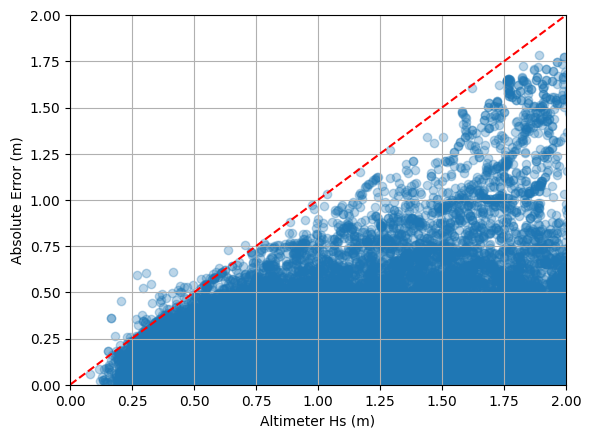

In [60]:
x = df_all["hs_altimeter"].values
y = df_all["hs_model_no_cur"].values
z = np.std(y-x)/np.mean(x)
plt.scatter(df_all["hs_altimeter"], abs(df_all["hs_model_no_cur"] - df_all["hs_altimeter"]), alpha=0.3)
#plt.scatter(x, z, alpha=0.3)
dmin, dmax = np.min([x, y]) * 0.9, np.max([x, y]) * 1.05
diag = np.linspace(dmin, dmax, 1000)
plt.plot(diag, diag, color='r', linestyle='--')
plt.grid(True)
plt.xlim(0,2)
plt.ylim(0,2)
plt.xlabel("Altimeter Hs (m)")
plt.ylabel("Absolute Error (m)")
plt.show()


Save the final pandas dataset into a csv

In [ ]:
#df_all.to_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//datasets//with_cur//matched_dataset_with_cur ({Region_saves}).csv",
#              index=False)

df_all.to_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//datasets//no_cur//matched_dataset_no_cur ({Region_saves}).csv",
              index=False)

QQ-plot fuction (from metocean stats)

In [ ]:
from metocean_stats import stats
import scipy.stats as st
def plot_scatter(df, var1, var2,
                 var1_units='m', var2_units='m',
                 title=' ',
                 regression_line='effective-variance',
                 qqplot=True, density=True,
                 output_file='scatter_plot.png',
                 annotation_position='bottom-right'):
    x = df[var1].values
    y = df[var2].values

    fig, ax = plt.subplots()

    # --------------------------
    # Scatter / Density plot
    # --------------------------
    if not density:
        ax.scatter(x, y, marker='.', s=10, c='g')
    else:
        #plt.hist2d(x, y, bins=50, cmap='hot', cmin=1)
        #plt.colorbar()
        h = ax.hist2d(x, y, bins=50, cmap='hot', cmin=1)
        fig.colorbar(h[3], ax=ax)    # h[3] is the QuadMesh

    dmin, dmax = np.min([x, y]) * 0.9, np.max([x, y]) * 1.05
    diag = np.linspace(dmin, dmax, 1000)
    ax.plot(diag, diag, color='r', linestyle='--')

    ax.set_aspect('equal')
    ax.set_xlim([0, dmax])
    ax.set_ylim([0, dmax])

    # --------------------------
    # QQ Plot
    # --------------------------
    if qqplot:
        percs = np.linspace(0, 100, 101)
        qn_x = np.nanpercentile(x, percs)
        qn_y = np.nanpercentile(y, percs)
        ax.scatter(qn_x, qn_y, marker='.', s=80, c='b')

    # --------------------------
    # Regression line
    # --------------------------
    if regression_line == 'least-squares':
        slope = st.linregress(x, y).slope
        intercept = st.linregress(x, y).intercept

    elif regression_line == 'mean-slope':
        slope = np.mean(y) / np.mean(x)
        intercept = 0

    elif regression_line == 'effective-variance':
        slope = stats.linfitef(x, y)[0]
        intercept = stats.linfitef(x, y)[1]

    else:
        slope = None
        intercept = None

    if slope is not None:
        if intercept > 0:
            label = f"$y = {slope:.2f}x + {intercept:.2f}$"
        elif intercept < 0:
            label = f"$y = {slope:.2f}x - {abs(intercept):.2f}$"
        else:
            label = f"$y = {slope:.2f}x$"

        ax.plot(x, slope * x + intercept, 'k--', label=label)
        ax.legend(loc='best')

    # --------------------------
    # Statistics
    # --------------------------
    rmse = np.sqrt(((y - x) ** 2).mean())
    bias = np.mean(y - x)
    mae = np.mean(np.abs(y - x))
    corr = np.corrcoef(y, x)[0][1]
    si = np.std(x - y) / np.mean(x)

    stats_text = (
        f"\nbias = {bias:.3f}"
        f"rmse = {rmse:.3f}"
        #f"\nmae = {mae:.3f}"
        f"\ncorr = {corr:.3f}"
        f"\nsi = {si:.3f}"
    )

    # --------------------------
    # Annotation placement
    # --------------------------
    positions = {
        'bottom-right': (0.98, 0.02),
        'bottom-left':  (0.02, 0.02),
        'top-right':    (0.98, 0.98),
        'top-left':     (0.02, 0.98)
    }

    xy = positions.get(annotation_position, (0.98, 0.02))

    ax.annotate(
        stats_text,
        xy=xy,
        xycoords='axes fraction',
        ha='right' if 'right' in annotation_position else 'left',
        va='top' if 'top' in annotation_position else 'bottom',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
    )

    # --------------------------
    # Labels & title
    # --------------------------
    ax.set_xlabel(f"{var1}[{var1_units}]", fontsize=15)
    ax.set_ylabel(f"{var2}[{var2_units}]", fontsize=15)

    ax.set_title(
         (f"{title}, N={np.count_nonzero(~np.isnan(x)):.0f}"),
        fontsize=15)

    ax.grid()

    # --------------------------
    # Save figure
    # --------------------------
    if output_file:
        fig.savefig(output_file)

    return None


QQ-plots (Model vs altimeter observations)

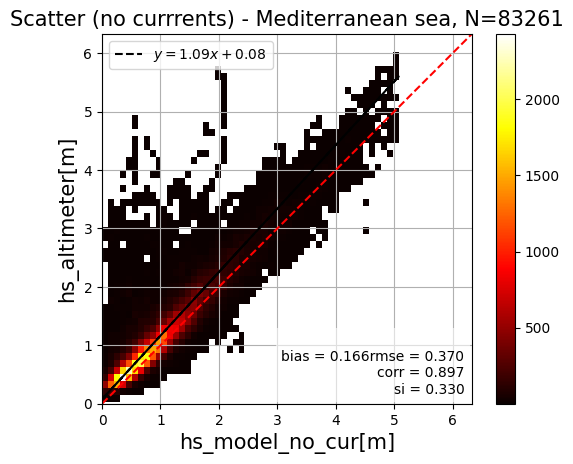

In [11]:
df = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//datasets//no_cur//matched_dataset_no_cur (Mediterrenean sea).csv")
df = df[df["value_qc"] == 1]
plot_scatter(df, var1='hs_model_no_cur', var2='hs_altimeter', annotation_position='bottom-right',
   var1_units='m',
   var2_units='m',
   title=f'Scatter (no currrents) - Mediterranean sea',
   regression_line='effective-variance',
   qqplot=False,
   density=True)
   #output_file=f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//Scatter_plots//with_cur//scatter_plot_with_cur ({Region_saves}).png")

Timeseries model's outputs vs altimeter observations

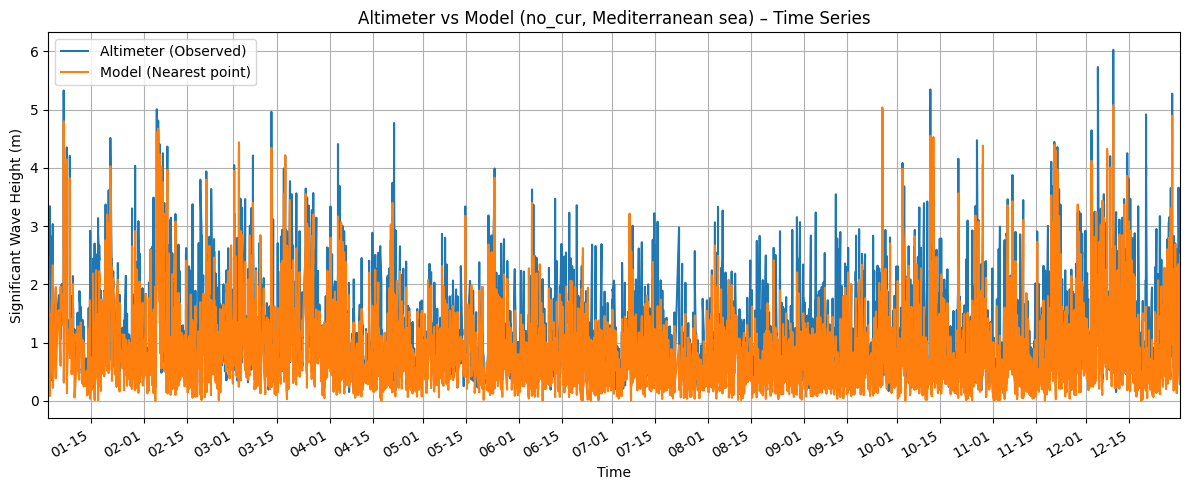

In [15]:
import matplotlib.pyplot as plt

# read matched dataset
df = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//datasets//no_cur//matched_dataset_no_cur (Mediterrenean sea).csv")
df = df[df["value_qc"] == 1]

# Ensure time is sorted
df_altim_plot = df.sort_values("time")
df_altim_plot["time"] = pd.to_datetime(df_altim_plot["time"])

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(df_altim_plot["time"], df_altim_plot["hs_altimeter"], 
         label="Altimeter (Observed)", linewidth=1.5)

ax.plot(df_altim_plot["time"], df_altim_plot["hs_model_no_cur"], 
         label="Model (Nearest point)", linewidth="1.5")

#plt.scatter(df_altim_plot["time"], df_altim_plot["value"], 
 #        label="Altimeter (Observed)", marker='o', color='blue', s=10, alpha=0.7) 
#plt.scatter(df_altim_plot["time"], df_altim_plot["hs_model"], marker='o', color='red', s=10, alpha=0.7, label="Model (Nearest point)") 

xmin = df_altim_plot["time"].min()
xmax = df_altim_plot["time"].max()
ax.set_xlim(xmin, xmax)

# 2. Use AutoDateLocator to avoid too many labels
locator = mdates.AutoDateLocator(minticks=15, maxticks=20)
formatter = mdates.DateFormatter("%m-%d")

ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

# Let matplotlib automatically choose tick spacing
fig.autofmt_xdate()

ax.set_xlabel("Time")
ax.set_ylabel("Significant Wave Height (m)")
ax.set_title(f"Altimeter vs Model (no_cur, Mediterranean sea) – Time Series")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

#output_file=f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//Time_series//with_cur//Altimeter_vs_model_hs (time series, with_cur - {Region_saves}).png"
#fig.savefig(output_file)

Compute an adaptive percentile range for plotting, depending on the data distribution.

In [20]:
import numpy as np
from scipy.stats import skew, kurtosis, normaltest

def adaptive_percentile_range(data):
    """ Compute an adaptive percentile range for plotting, 
    depending on the data distribution.
    Returns (lower_bound, upper_bound, coverage_percent)."""
    data = np.asarray(data)
    data = data[np.isfinite(data)]  # remove NaNs and infs

    # Basic distribution metrics
    s = skew(data)
    k = kurtosis(data)
    stat, pval = normaltest(data)  # normality test (null: normal)

    # Start with default 90% range
    coverage = 10.0
    
    # Adjust for heavy tails or skewed data
    if pval < 0.05:  # not normal
        if abs(s) > 1 or k > 3:       # strongly skewed or heavy tails
            #coverage = 10.0
            coverage = 90.0
        elif abs(s) > 0.5 or k > 1:   # moderately skewed
            #coverage = 10.0
            coverage = 93.0
    else:
        #coverage = 10.0  # almost normal, show more of the data
        coverage = 98.0  # almost normal, show more of the data

    lower = (100 - coverage) / 2
    upper = 100 - lower
    bounds = np.percentile(data, [lower, upper])

    return bounds, coverage


QQ-plot fuction for multiple plots (from metocean stats)

In [ ]:
from metocean_stats import stats
import scipy.stats as st
def plot_scatter_multiple(df, var1, var2, ax,
                 var1_units='m', var2_units='m',
                 title=' ', var1_name = '', var2_name = '',
                 regression_line='effective-variance',
                 qqplot=True, density=True, CBAR_SHRINK=1.0,
                 annonate_fontsize = 10,
                 #output_file='', 
                 annotation_position='bottom-right'):
    x = df[var1].values
    y = df[var2].values
    ax=ax

    # ------------------------------------
    # Apply percentile filtering
    # ------------------------------------
    bounds_hs_var1,_ = adaptive_percentile_range(x)
    min_hs_var1, max_hs_var1 = bounds_hs_var1

    bounds_hs_var2,_ = adaptive_percentile_range(y)
    min_hs_var2, max_hs_var2 = bounds_hs_var2

    mask = (
        (x >= min_hs_var1) & (x <= max_hs_var1) &
        (y >= min_hs_var2) & (y <= max_hs_var2)
    )

    a = x[mask]
    b = y[mask]

    # --------------------------
    # Scatter / Density plot
    # --------------------------
    if not density:
        ax.scatter(x, y, marker='.', s=10, c='g')
    else:
        #plt.hist2d(x, y, bins=50, cmap='hot', cmin=1)
        #plt.colorbar()
        h = ax.hist2d(a, b, bins=50, cmap='hot', cmin=1)
        fig.colorbar(h[3], ax=ax, shrink=CBAR_SHRINK)    # h[3] is the QuadMesh

    # diagonal line
    dmin, dmax = np.min([a, b]) * 0.9, np.max([a, b]) * 1.05
    diag = np.linspace(dmin, dmax, 1000)
    ax.plot(diag, diag, color='r', linestyle='--')

    # -----------------
    # extent x-y axes
    # -----------------
    ax.set_aspect('equal')
    #ax.set_xlim([0, dmax])
    #ax.set_ylim([0, dmax])

    if max_hs_var1 > max_hs_var2:
        ax.set_xlim([0, 1.1*max_hs_var1])
        ax.set_ylim([0, 1.1*max_hs_var1])
    else:
        ax.set_xlim([0, 1.1*max_hs_var2])
        ax.set_ylim([0, 1.1*max_hs_var2])

    # --------------------------
    # QQ Plot
    # --------------------------
    if qqplot:
        percs = np.linspace(0, 100, 101)
        qn_x = np.nanpercentile(x, percs)
        qn_y = np.nanpercentile(y, percs)
        ax.scatter(qn_x, qn_y, marker='.', s=80, c='b')

    # --------------------------
    # Regression line
    # --------------------------
    if regression_line == 'least-squares':
        slope = st.linregress(x, y).slope
        intercept = st.linregress(x, y).intercept

    elif regression_line == 'mean-slope':
        slope = np.mean(y) / np.mean(x)
        intercept = 0

    elif regression_line == 'effective-variance':
        slope = stats.linfitef(a, b)[0]
        intercept = stats.linfitef(a, b)[1]

    else:
        slope = None
        intercept = None

    if slope is not None:
        if intercept > 0:
            label = f"$y = {slope:.2f}x + {intercept:.2f}$"
        elif intercept < 0:
            label = f"$y = {slope:.2f}x - {abs(intercept):.2f}$"
        else:
            label = f"$y = {slope:.2f}x$"

        ax.plot(x, slope * x + intercept, 'k--', label=label, c='b')
        ax.legend(loc='best')

    # --------------------------
    # Statistics
    # --------------------------
    rmse = np.sqrt(((b - a) ** 2).mean())
    bias = np.mean(b - a)
    mae = np.mean(np.abs(b - a))
    corr = np.corrcoef(b, a)[0][1]
    si = np.std(a - b) / np.mean(a)

    stats_text = (
        f"Entries = {np.count_nonzero(~np.isnan(x)):.0f}"
        #f"\nMean M = {np.nanmean(b):.2f}"
        #f"\nMean B = {np.nanmean(a):.2f}"
        #f"\nStd M = {np.nanstd(b):.2f}"
        #f"\nStd B = {np.nanstd(a):.2f}"
        f"\nBIAS = {bias:.3f}"
        f"\nRMSE = {rmse:.3f}"
        #f"\nMAE = {mae:.3f}"
        f"\nCORR = {corr:.3f}"
        f"\nSI = {si:.3f}"
    )

    # --------------------------
    # Annotation placement
    # --------------------------
    positions = {
        'bottom-right': (0.98, 0.02),
        'bottom-left':  (0.02, 0.02),
        'top-right':    (0.98, 0.98),
        'top-left':     (0.02, 0.98)
    }

    xy = positions.get(annotation_position, (0.98, 0.02))

    ax.annotate(
        stats_text, color="white",
        xy=xy,
        xycoords='axes fraction',
        ha='right' if 'right' in annotation_position else 'left',
        va='top' if 'top' in annotation_position else 'bottom',
        fontsize=annonate_fontsize,
        bbox=dict(facecolor='black', alpha=0.9, edgecolor='none')
    )

    # --------------------------
    # Labels & title
    # --------------------------
    ax.set_xlabel(f"{var1_name}[{var1_units}]", fontsize=15)
    ax.set_ylabel(f"{var2_name}[{var2_units}]", fontsize=15)

    ax.set_title(
        title,
        fontsize=15
    )

    ax.grid()

    # --------------------------
    # Save figure
    # --------------------------
    #if output_file:
    #    fig.savefig(output_file)

    return None


Multiple QQ-plots

C:\Users\kosta\AppData\Local\Temp\ipykernel_7580\3016966635.py:115: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x, slope * x + intercept, 'k--', label=label, c='b')
C:\Users\kosta\AppData\Local\Temp\ipykernel_7580\3016966635.py:115: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x, slope * x + intercept, 'k--', label=label, c='b')
C:\Users\kosta\AppData\Local\Temp\ipykernel_7580\3016966635.py:115: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x, slope * x + intercept, 'k--', label=label, c='b')
C:\Users\kosta\AppData\Local\Temp\ipykernel_7580\3016966635.py:115: UserWarning: color is redundantly defined by the 'color' keyword 

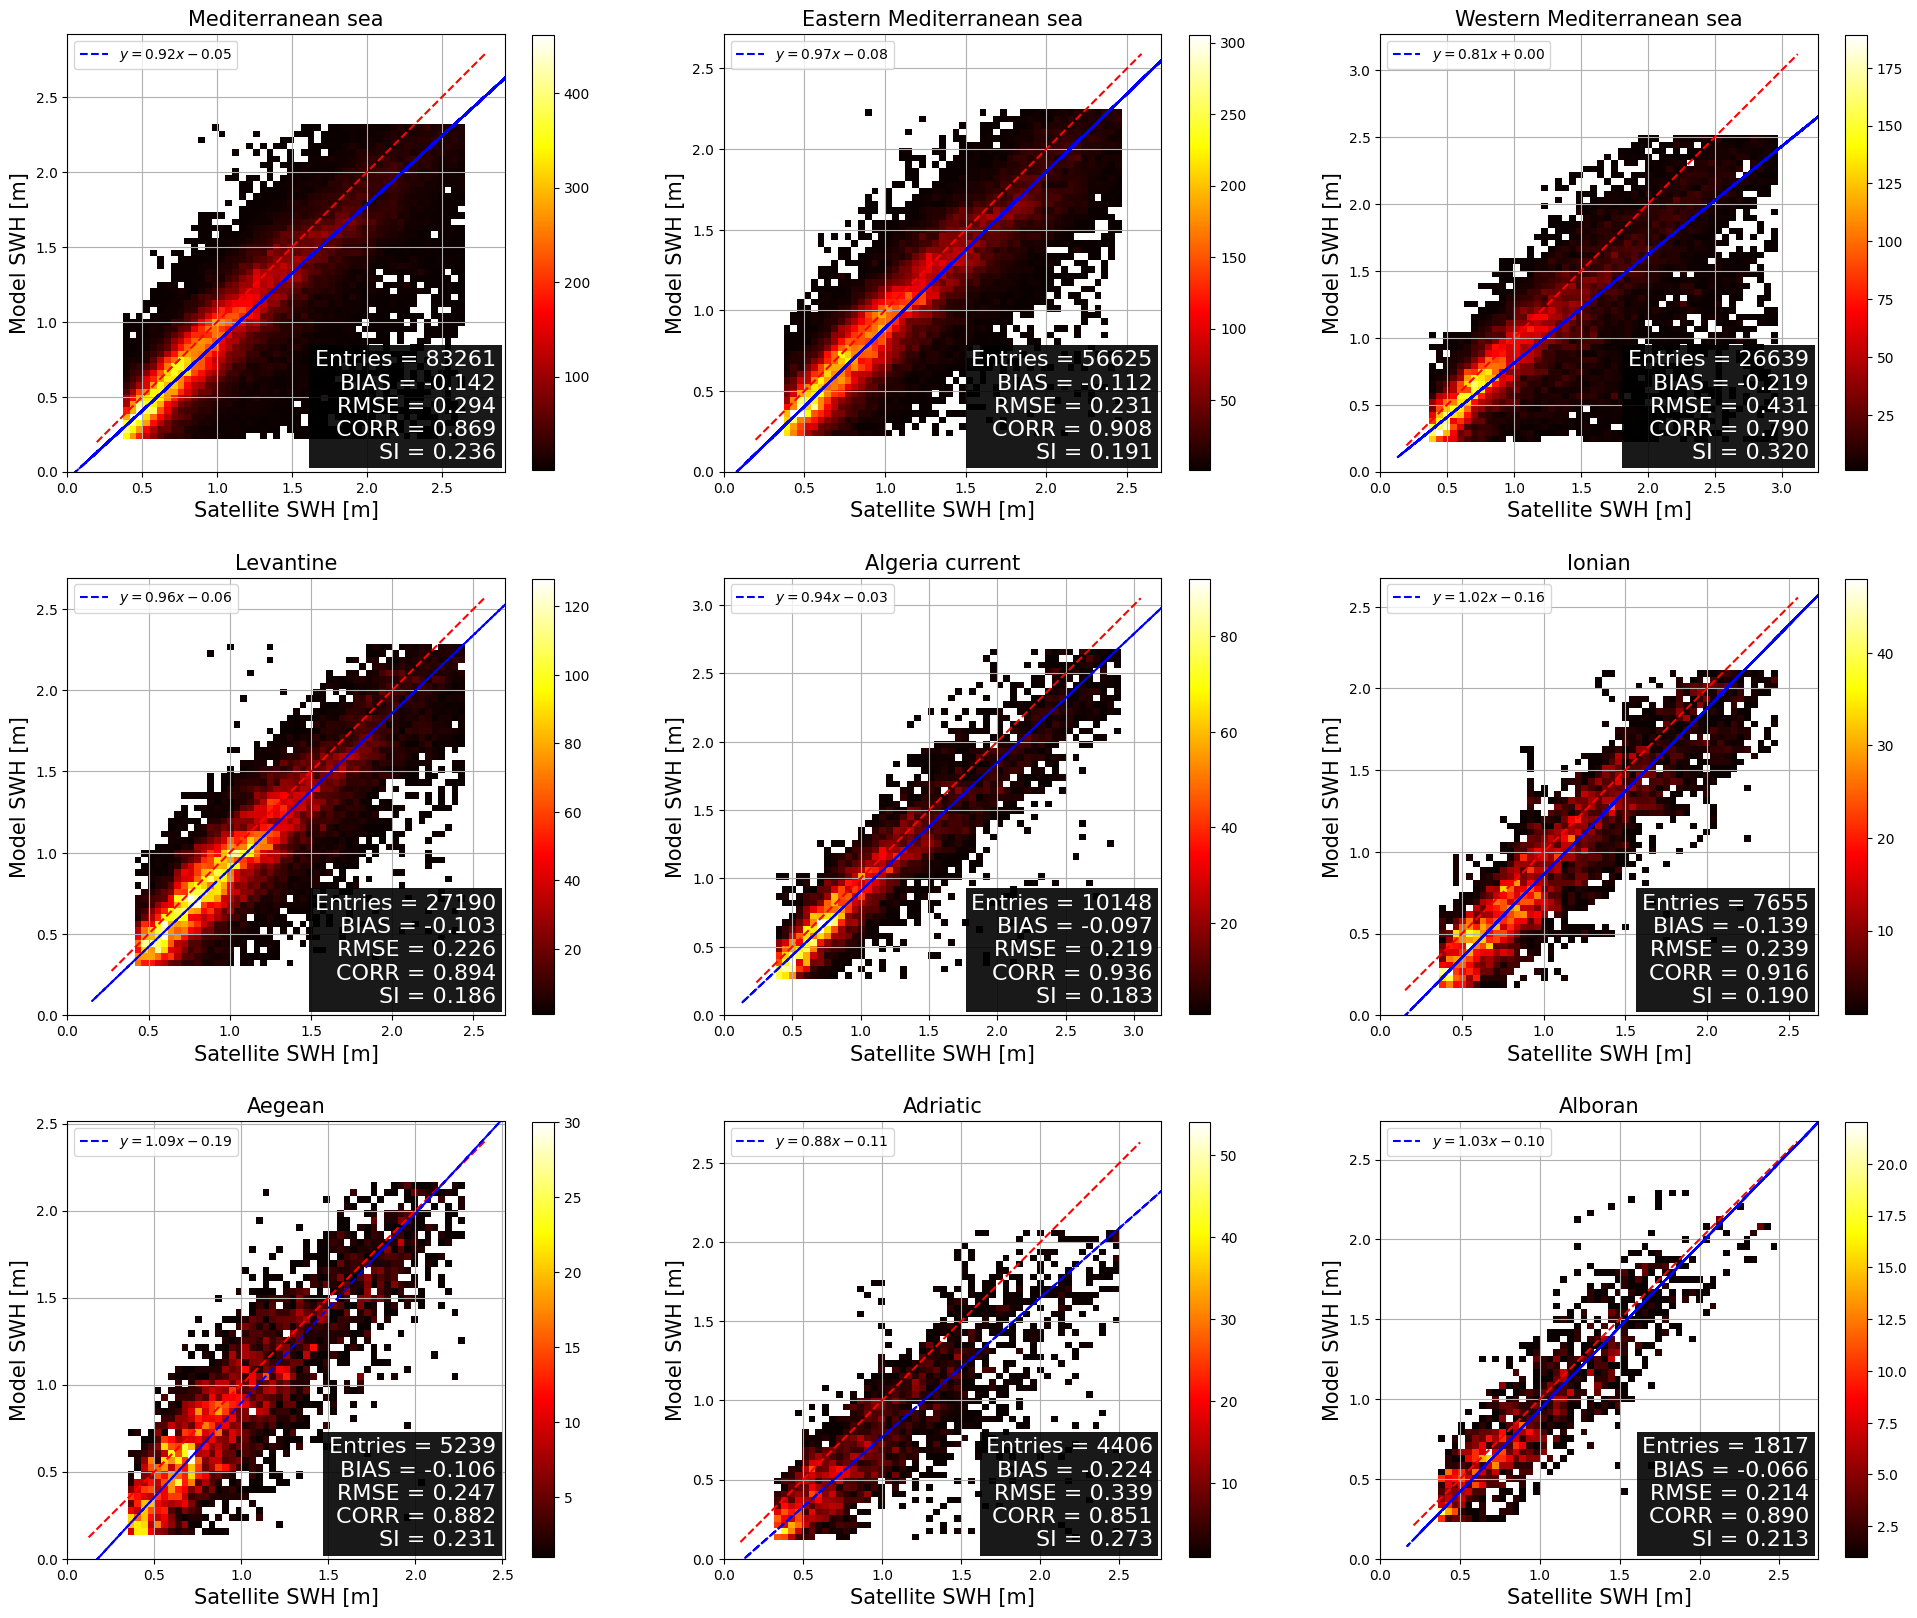

In [21]:
# Define regions of interest
Regions = {
    "Mediterranean sea":      {"i":0,"lon_min": -10,  "lon_max": 37, "lat_min": 30, "lat_max": 48},
    "Eastern Mediterranean sea":      {"i":1, "lon_min": 11,  "lon_max": 37, "lat_min": 30, "lat_max": 48},
    "Western Mediterranean sea":      {"i":2, "lon_min": -10,  "lon_max": 11, "lat_min": 30, "lat_max": 48},
    "Levantine":   {"i":3, "lon_min": 19.5,  "lon_max": 36.5,   "lat_min": 30.5, "lat_max": 37.5},
    "Algeria current":    {"i":4, "lon_min": -1,  "lon_max": 9.8, "lat_min": 35, "lat_max": 40},    
    "Ionian":      {"i":5, "lon_min": 15,  "lon_max": 23.5, "lat_min": 36, "lat_max": 40},
    "Aegean":      {"i":6, "lon_min": 22,"lon_max": 28,   "lat_min": 35.5, "lat_max": 41},
    "Adriatic":    {"i":7, "lon_min": 12,  "lon_max": 19.5, "lat_min": 40, "lat_max": 46},    
    "Alboran":    {"i":8, "lon_min": -6,  "lon_max": -1, "lat_min": 35, "lat_max": 37},
    }

fig = plt.figure(figsize=(24, 20))
ax1 = fig.add_subplot(3, 3, 1)
ax2 = fig.add_subplot(3, 3, 2)
ax3 = fig.add_subplot(3, 3, 3)
ax4 = fig.add_subplot(3, 3, 4)
ax5 = fig.add_subplot(3, 3, 5)
ax6 = fig.add_subplot(3, 3, 6)
ax7 = fig.add_subplot(3, 3, 7)
ax8 = fig.add_subplot(3, 3, 8)
ax9 = fig.add_subplot(3, 3, 9)

axes = ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9

for name, r in Regions.items():
    df_all = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//datasets//no_cur//matched_dataset_no_cur (Mediterrenean sea).csv")
    df_all = df_all[df_all["value_qc"] == 1]
    df_all = df_all[
        (df_all.longitude >= r["lon_min"]) &
        (df_all.longitude <= r["lon_max"]) &
        (df_all.latitude  >= r["lat_min"]) &
        (df_all.latitude  <= r["lat_max"])
    ]

    plot_scatter_multiple(df_all, ax=axes[r["i"]], var1='hs_altimeter', var2='hs_model_no_cur',
             annotation_position='bottom-right',
   var1_units='m', var1_name="Satellite SWH ",
   var2_units='m', var2_name="Model SWH ",
   title=f'{name}', CBAR_SHRINK = 0.96,
   regression_line='effective-variance', annonate_fontsize=16,
   qqplot=False,
   density=True)

Compute metrics for different sub-regions in the Mediterranean sea

In [ ]:
regions = {
    "Ionian":      {"lon_min": 15,  "lon_max": 23.5, "lat_min": 36, "lat_max": 39.5},
    #"Aegean":      {"lon_min": 22,"lon_max": 28,   "lat_min": 35.5, "lat_max": 41},
    "Levantine":   {"lon_min": 22,  "lon_max": 36.5,   "lat_min": 30.5, "lat_max": 37.5},
    "Aegean":      {"lon_min": 22,"lon_max": 28.1,   "lat_min": 35.8, "lat_max": 41},
    "Tyrrhenian_1":    {"lon_min": 8.5,  "lon_max": 14.5, "lat_min": 40, "lat_max": 43.5},
    "Tyrrhenian_2":    {"lon_min": 8.5,  "lon_max": 16, "lat_min": 37.5, "lat_max": 41},
    "Adriatic_1":    {"lon_min": 12,  "lon_max": 19.5, "lat_min": 43, "lat_max": 46},
    "Adriatic_2":    {"lon_min": 14,  "lon_max": 19.5, "lat_min": 41, "lat_max": 43},
    "Adriatic_3":    {"lon_min": 15.8,  "lon_max": 20.5, "lat_min": 39.5, "lat_max": 41},    
    "Gulf of Sidra":    {"lon_min": 15,  "lon_max": 20.5, "lat_min": 30, "lat_max": 32.5},
    "Sicily":    {"lon_min": 9.5,  "lon_max": 16, "lat_min": 32, "lat_max": 38.2},
    "Ligurian":    {"lon_min": 6.5,  "lon_max": 11, "lat_min": 42, "lat_max": 44.5},
    "Gulf of Lions":    {"lon_min": 3,  "lon_max": 6.5, "lat_min": 42, "lat_max": 44},
    "Balearic":    {"lon_min": -1,  "lon_max": 8.5, "lat_min": 38, "lat_max": 42},
    "Alboran":    {"lon_min": -6,  "lon_max": -1, "lat_min": 35, "lat_max": 38},
    "Algeria":    {"lon_min": -1,  "lon_max": 9.8, "lat_min": 35, "lat_max": 40},
    "central_med":    {"lon_min": 16,  "lon_max": 22, "lat_min": 32, "lat_max": 36}
    
}
ds_full = xr.open_dataset(
    "C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Maps_diff//hs_mean_diff01.nc",
    engine="h5netcdf"
)

df_full = pd.read_csv(
    "C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//datasets//no_cur//matched_dataset_no_cur (Mediterrenean sea).csv"
)
df_full = df_full[df_full["value_qc"] == 1]

bias_med = xr.full_like(ds_full["diff"].isel(time=0), np.nan)
rmse_med = xr.full_like(ds_full["diff"].isel(time=0), np.nan)
corr_med = xr.full_like(ds_full["diff"].isel(time=0), np.nan)
si_med = xr.full_like(ds_full["diff"].isel(time=0), np.nan)
lon2d, lat2d = xr.broadcast(bias_med.longitude, bias_med.latitude)

region_bias = {}
region_rmse = {}
region_corr = {}
region_si = {}

for name, r in regions.items():

    # -------------------------------
    # Subset gridded dataset
    # -------------------------------
    ds_reg = ds_full.where(
        (ds_full.longitude >= r["lon_min"]) &
        (ds_full.longitude <= r["lon_max"]) &
        (ds_full.latitude  >= r["lat_min"]) &
        (ds_full.latitude  <= r["lat_max"]),
        drop=True
    )

    # -------------------------------
    # Subset matchup dataframe
    # -------------------------------
    df_reg = df_full[
        (df_full.longitude >= r["lon_min"]) &
        (df_full.longitude <= r["lon_max"]) &
        (df_full.latitude  >= r["lat_min"]) &
        (df_full.latitude  <= r["lat_max"])
    ]

    if df_reg.empty:
        continue

    # -------------------------------
    # Bias calculation
    # -------------------------------
    x = df_reg["hs_altimeter"]
    y = df_reg["hs_model_no_cur"]

    bounds_x,_ = adaptive_percentile_range(x)
    bounds_y,_ = adaptive_percentile_range(y)

    mask = (
        (x >= bounds_x[0]) & (x <= bounds_x[1]) &
        (y >= bounds_y[0]) & (y <= bounds_y[1])
    )

    BIAS = np.mean(y[mask] - x[mask])
    RMSE = np.sqrt(((y[mask] - x[mask]) ** 2).mean())
    CORR = np.corrcoef(y[mask], x[mask])[0][1]
    SI = np.std(x[mask] - y[mask]) / np.mean(x[mask])

    region_mask = (
        (lon2d >= r["lon_min"]) & (lon2d <= r["lon_max"]) &
        (lat2d >= r["lat_min"]) & (lat2d <= r["lat_max"])
    )

    bias_med = xr.where(region_mask, BIAS, bias_med)
    rmse_med = xr.where(region_mask, RMSE, rmse_med)
    corr_med = xr.where(region_mask, CORR, corr_med)
    si_med = xr.where(region_mask, SI, si_med)

# Apply ocean/topography mask
    bias_med = bias_med.where(ds_full["diff"].isel(time=0).notnull())
    rmse_med = rmse_med.where(ds_full["diff"].isel(time=0).notnull())
    corr_med = corr_med.where(ds_full["diff"].isel(time=0).notnull())
    si_med = si_med.where(ds_full["diff"].isel(time=0).notnull())

    region_bias[name] = {
    "bias": BIAS,
    "lon_c": 0.5 * (r["lon_min"] + r["lon_max"]),
    "lat_c": 0.5 * (r["lat_min"] + r["lat_max"])}

    region_rmse[name] = {
    "bias": RMSE,
    "lon_c": 0.5 * (r["lon_min"] + r["lon_max"]),
    "lat_c": 0.5 * (r["lat_min"] + r["lat_max"])}

    region_corr[name] = {
    "bias": CORR,
    "lon_c": 0.5 * (r["lon_min"] + r["lon_max"]),
    "lat_c": 0.5 * (r["lat_min"] + r["lat_max"])}

    region_si[name] = {
    "bias": SI,
    "lon_c": 0.5 * (r["lon_min"] + r["lon_max"]),
    "lat_c": 0.5 * (r["lat_min"] + r["lat_max"])}


Map of bias in different sub-regions 

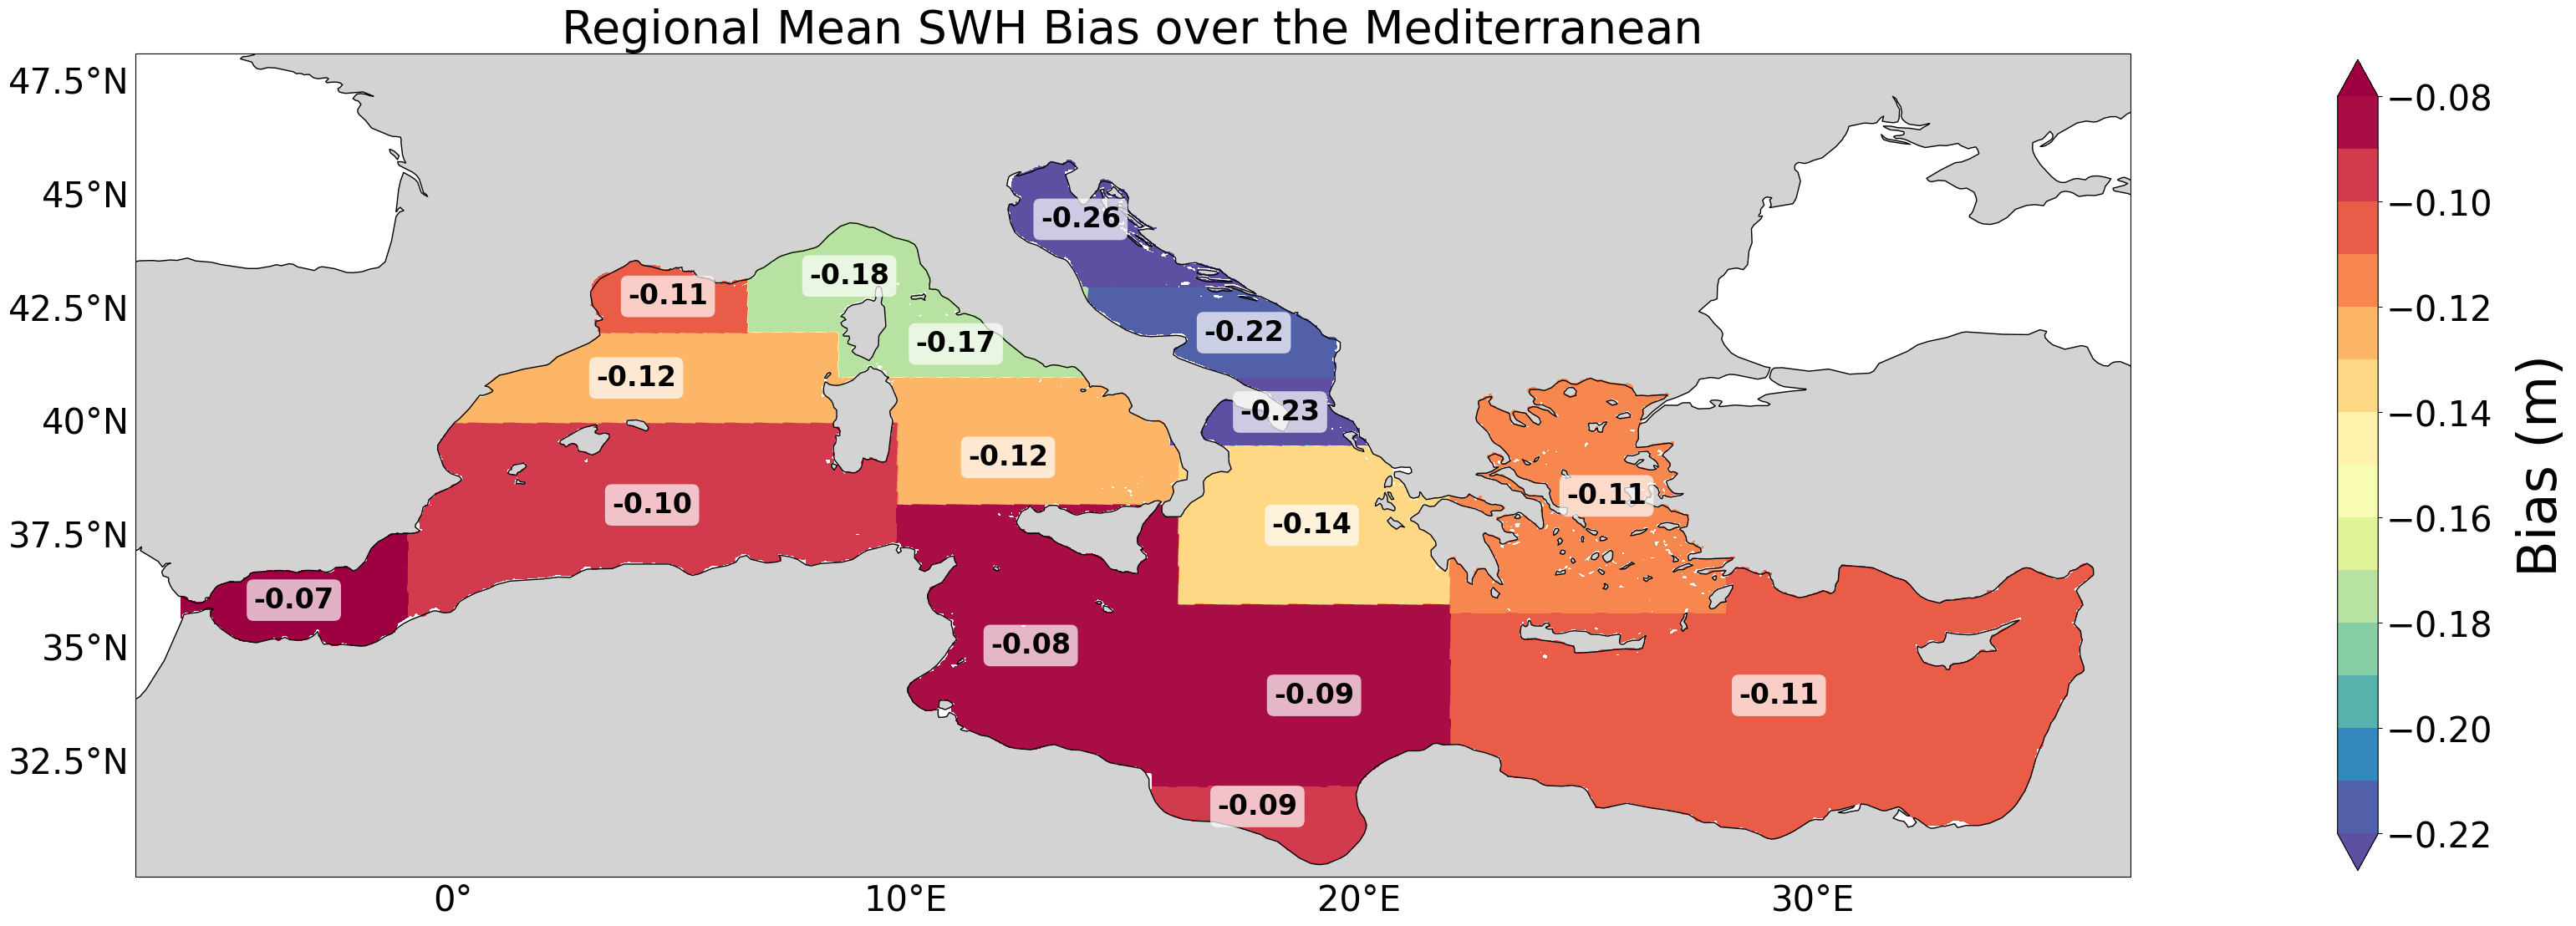

In [ ]:
fig = plt.figure(figsize=(40, 18))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-7, 37, 30, 46])
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE)

bounds_bias,_ = adaptive_percentile_range(bias_med)
min_bias, max_bias = bounds_bias
norm_1 = mcolors.Normalize(vmin=min_bias, vmax=max_bias)
levels_1 = np.round(np.linspace(min_bias, max_bias, 51), 
                        2)
levels_1 = np.unique(levels_1)

cf = ax.contourf(
    bias_med.longitude,
    bias_med.latitude,
    bias_med,
    transform=ccrs.PlateCarree(),
    levels=levels_1,
    norm=norm_1,
    cmap="Spectral_r",
    #cmap="YlGnBu",
    #cmap='RdYlBu',
    #cmap='RdBu',
    extend="both"
)

cbar = fig.colorbar(cf, pad=0.08, ax=ax, label="Mean SWH Bias (m)", shrink=0.7)
cbar.set_label(label="Bias (m)", size=46, labelpad=20)
cbar.ax.tick_params(labelsize=30)
ax.set_title("Regional Mean SWH Bias over the Mediterranean", fontsize=40)
gl = ax.gridlines(draw_labels=True, alpha = 0)
gl.right_labels = False
gl.top_labels = False
gl.xlabel_style = {'size': 30}
gl.ylabel_style = {'size': 30}

label_offsets = {
    "Adriatic_1":   {"dlon": -1.9},
    "Adriatic_2":   {"dlon": 0.7},
    "Adriatic_3":   {"dlon": 0.1},
    "Aegean":       {"dlon": 0.4},
    "Ionian":       {"dlon": -0.3},
    "Tyrrhenian_1":   {"dlon": -0.4},
    "Balearic":     {"dlat": 1.0, "dlon": 0.3},
    "Algeria":      {"dlat": 0.7},
    "Alboran":      {"dlat": -0.4},
    "Gulf of Lions":      {"dlat": -0.2},
    "Gulf of Sidra":  {"dlat": 0.3}
}

for name, info in region_bias.items():

    dlon = label_offsets.get(name, {}).get("dlon", 0.0)
    dlat = label_offsets.get(name, {}).get("dlat", 0.0)

    ax.text(
        info["lon_c"] + dlon,
        info["lat_c"] + dlat,
        f"{info['bias']:.2f}",
        transform=ccrs.PlateCarree(),
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.7
        )
    )


Fuction for plots style

In [26]:
def style_axis(ax, no_left_labels=False, no_bottom_labels=False):
    from matplotlib.ticker import MultipleLocator

    ax.coastlines()
    ax.set_extent([-7, 37, 30, 46])
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, zorder=1, edgecolor='k')
    ax.add_feature(cfeature.RIVERS, linewidth=0.5)
    
    """gl = ax.gridlines(draw_labels=True, alpha = 0)
    gl.right_labels = False
    gl.top_labels = False

    if no_left_labels:
        gl.left_labels = False

    if no_bottom_labels:
        gl.bottom_labels = False
    
    gl.xlabel_style = {'size': 40}
    gl.ylabel_style = {'size': 40}

    #gl.xlocator = MultipleLocator(1)
    gl.ylocator = MultipleLocator(4)"""

    return ax

Maps in different sub-regions of validation metrics 

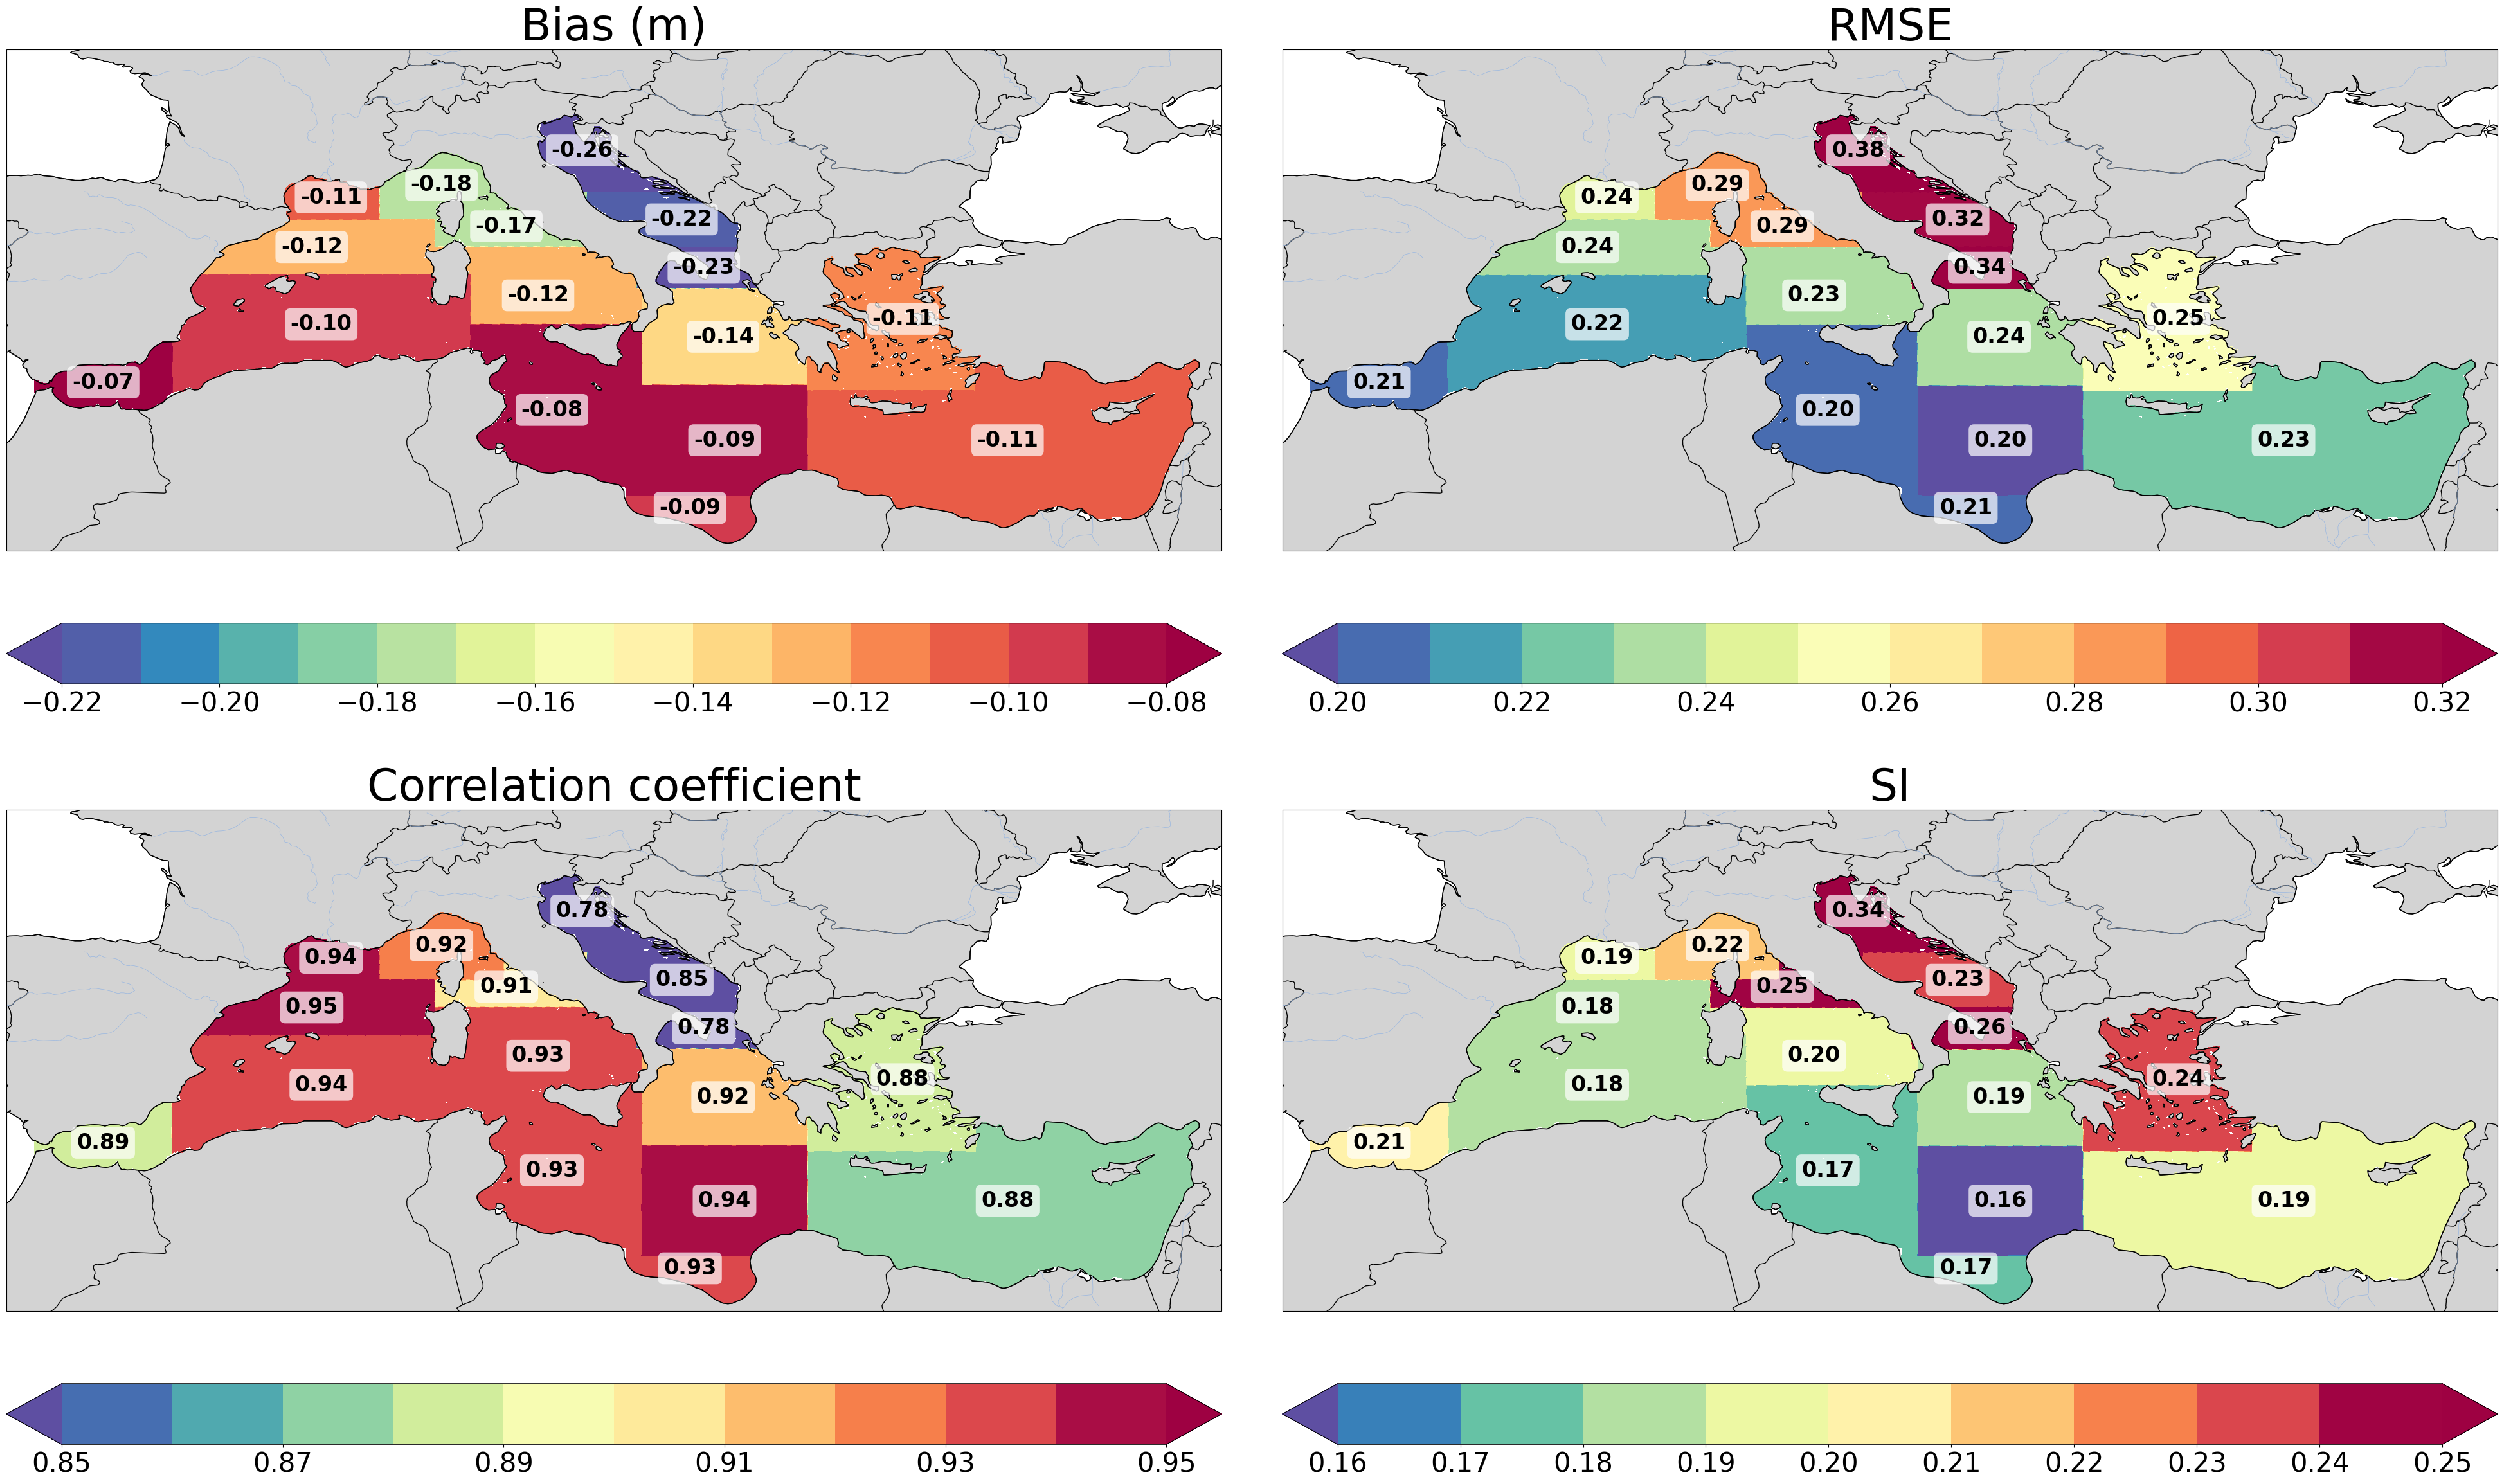

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(50, 30), subplot_kw=
                            {'projection': ccrs.PlateCarree()})
ax1, ax2, ax3, ax4 = axes.flatten()
axes_list=[ax1,ax2,ax3,ax4]
SHRINK=1.0
plt.subplots_adjust(hspace=0.05,wspace=0.05)  # increase vertical spacing

bounds_bias,_ = adaptive_percentile_range(bias_med)
min_bias, max_bias = bounds_bias
norm_1 = mcolors.Normalize(vmin=min_bias, vmax=max_bias)
levels_1 = np.round(np.linspace(min_bias, max_bias, 51), 
                        2)
levels_1 = np.unique(levels_1)

cf = ax1.contourf(
    bias_med.longitude,
    bias_med.latitude,
    bias_med,
    transform=ccrs.PlateCarree(),
    levels=levels_1,
    norm=norm_1,
    cmap="Spectral_r",
    #cmap="YlGnBu",
    #cmap='RdYlBu',
    #cmap='RdBu',
    extend="both"
)

cbar = fig.colorbar(cf, pad=0.1, ax=ax1, shrink=SHRINK,orientation='horizontal')
#cbar.set_label(label="Bias (m)", size=46, labelpad=20)
cbar.ax.tick_params(labelsize=30)
ax1.set_title("Bias (m)", fontsize=50)
style_axis(ax1)

bounds_bias,_ = adaptive_percentile_range(rmse_med)
min_bias, max_bias = bounds_bias
norm_2 = mcolors.Normalize(vmin=min_bias, vmax=max_bias)
levels_2 = np.round(np.linspace(min_bias, max_bias, 51), 
                        2)
levels_2 = np.unique(levels_2)

cf = ax2.contourf(
    rmse_med.longitude,
    rmse_med.latitude,
    rmse_med,
    transform=ccrs.PlateCarree(),
    levels=levels_2,
    norm=norm_2,
    cmap="Spectral_r",
    #cmap="YlGnBu",
    #cmap='RdYlBu',
    #cmap='RdBu',
    extend="both"
)

cbar = fig.colorbar(cf, pad=0.1, ax=ax2, shrink=SHRINK,orientation='horizontal')
#cbar.set_label(label="RMSE", size=46, labelpad=20)
cbar.ax.tick_params(labelsize=30)
ax2.set_title("RMSE", fontsize=50)
style_axis(ax2, no_left_labels=True)

bounds_bias,_ = adaptive_percentile_range(corr_med)
min_bias, max_bias = bounds_bias
norm_3 = mcolors.Normalize(vmin=min_bias, vmax=max_bias)
levels_3 = np.round(np.linspace(min_bias, max_bias, 51), 
                        2)
levels_3 = np.unique(levels_3)

cf = ax3.contourf(
    corr_med.longitude,
    corr_med.latitude,
    corr_med,
    transform=ccrs.PlateCarree(),
    levels=levels_3,
    norm=norm_3,
    cmap="Spectral_r",
    #cmap="YlGnBu",
    #cmap='RdYlBu',
    #cmap='RdBu',
    extend="both"
)

cbar = fig.colorbar(cf, pad=0.1, ax=ax3, shrink=SHRINK,orientation='horizontal')
#cbar.set_label(label="Correlation coef.", size=46, labelpad=20)
cbar.ax.tick_params(labelsize=30)
ax3.set_title("Correlation coefficient", fontsize=50)
style_axis(ax3)

bounds_bias,_ = adaptive_percentile_range(si_med)
min_bias, max_bias = bounds_bias
norm_4 = mcolors.Normalize(vmin=min_bias, vmax=max_bias)
levels_4 = np.round(np.linspace(min_bias, max_bias, 51), 
                        2)
levels_4 = np.unique(levels_4)

cf = ax4.contourf(
    si_med.longitude,
    si_med.latitude,
    si_med,
    transform=ccrs.PlateCarree(),
    levels=levels_4,
    norm=norm_4,
    cmap="Spectral_r",
    #cmap="YlGnBu",
    #cmap='RdYlBu',
    #cmap='RdBu',
    extend="both"
)

cbar = fig.colorbar(cf, pad=0.1, ax=ax4, shrink=SHRINK,orientation='horizontal')
#cbar.set_label(label="SI", size=46, labelpad=20)
cbar.ax.tick_params(labelsize=30)
ax4.set_title("SI", fontsize=50)
style_axis(ax4, no_left_labels=True)

label_offsets = {
    "Adriatic_1":   {"dlon": -1.9},
    "Adriatic_2":   {"dlon": 0.7},
    "Adriatic_3":   {"dlon": 0.1},
    "Aegean":       {"dlon": 0.4},
    "Ionian":       {"dlon": -0.3},
    "Tyrrhenian_1":   {"dlon": -0.4},
    "Balearic":     {"dlat": 1.0, "dlon": 0.3},
    "Algeria":      {"dlat": 0.7},
    "Alboran":      {"dlat": -0.4},
    "Gulf of Lions":      {"dlat": -0.2},
    "Gulf of Sidra":  {"dlat": 0.3}}

region_list = [region_bias,region_rmse,region_corr,region_si]

for j in range(0,len(axes_list)):
    for name, info in region_list[j].items():

            dlon = label_offsets.get(name, {}).get("dlon", 0.0)
            dlat = label_offsets.get(name, {}).get("dlat", 0.0)

            axes_list[j].text(
                info["lon_c"] + dlon,
                info["lat_c"] + dlat,
                f"{info['bias']:.2f}",
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=24,
                fontweight="bold",
                color="black",
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.7
                )
            )



Buoys metrics for each platform

In [28]:
BIAS_buoy = np.zeros(10)
CORR_buoy = np.zeros(10)
SI_buoy = np.zeros(10)
RMSE_buoy = np.zeros(10)
Platforms_list = ['ADN-DWRG1', 'OBSEA', '6100021', 'Malaga-coast-buoy', 
                  'Kariani', 'ATHOS', 'Melilla-coast-buoy',
                  'MYKON', 'HERAKLION', '61499']
for i in range(len(Platforms_list)):
    df_all = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//complete_matched_datasets//no_cur//matched_dataset_no_cur (Med).csv")
    df_all[df_all["value_qc"] == 1]
    df_platforms = df_all[df_all["platform_id"] == Platforms_list[i]]
    x = df_platforms['hs_buoys']
    y = df_platforms['hs_model_no_cur']
    bounds_hs_var1,_ = adaptive_percentile_range(x)
    min_hs_var1, max_hs_var1 = bounds_hs_var1

    bounds_hs_var2,_ = adaptive_percentile_range(y)
    min_hs_var2, max_hs_var2 = bounds_hs_var2

    # ------------------------------------
    # Apply percentile filtering
    # ------------------------------------
    mask = (
        (x >= min_hs_var1) & (x <= max_hs_var1) &
        (y >= min_hs_var2) & (y <= max_hs_var2)
    )

    a = x[mask]
    b = y[mask]

    BIAS_buoy[i] = np.mean(b - a)
    CORR_buoy[i] = np.corrcoef(b, a)[0][1]
    SI_buoy[i] = np.std(a - b) / np.mean(a)
    RMSE_buoy[i] = np.sqrt(((b - a) ** 2).mean())

Altimeter - Buoys plots (option 1)

'# Define the full path for the file, including the non-existent directory\n    output_file = f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Pure analysis//Complex analysis (relative angle & vorticity)//SWH//{Region_saves}//complex_plot_{List_seasons[j]} ({Region_plots}).png"\n\n    # Extract the directory path from the file path\n    directory = os.path.dirname(output_file)\n\n    # Create the directory if it does not exist, including any intermediate directories\n    if not os.path.exists(directory):\n        os.makedirs(directory, exist_ok=True) # exist_ok=True prevents error if dir already exists\n\n    fig.savefig(output_file)'

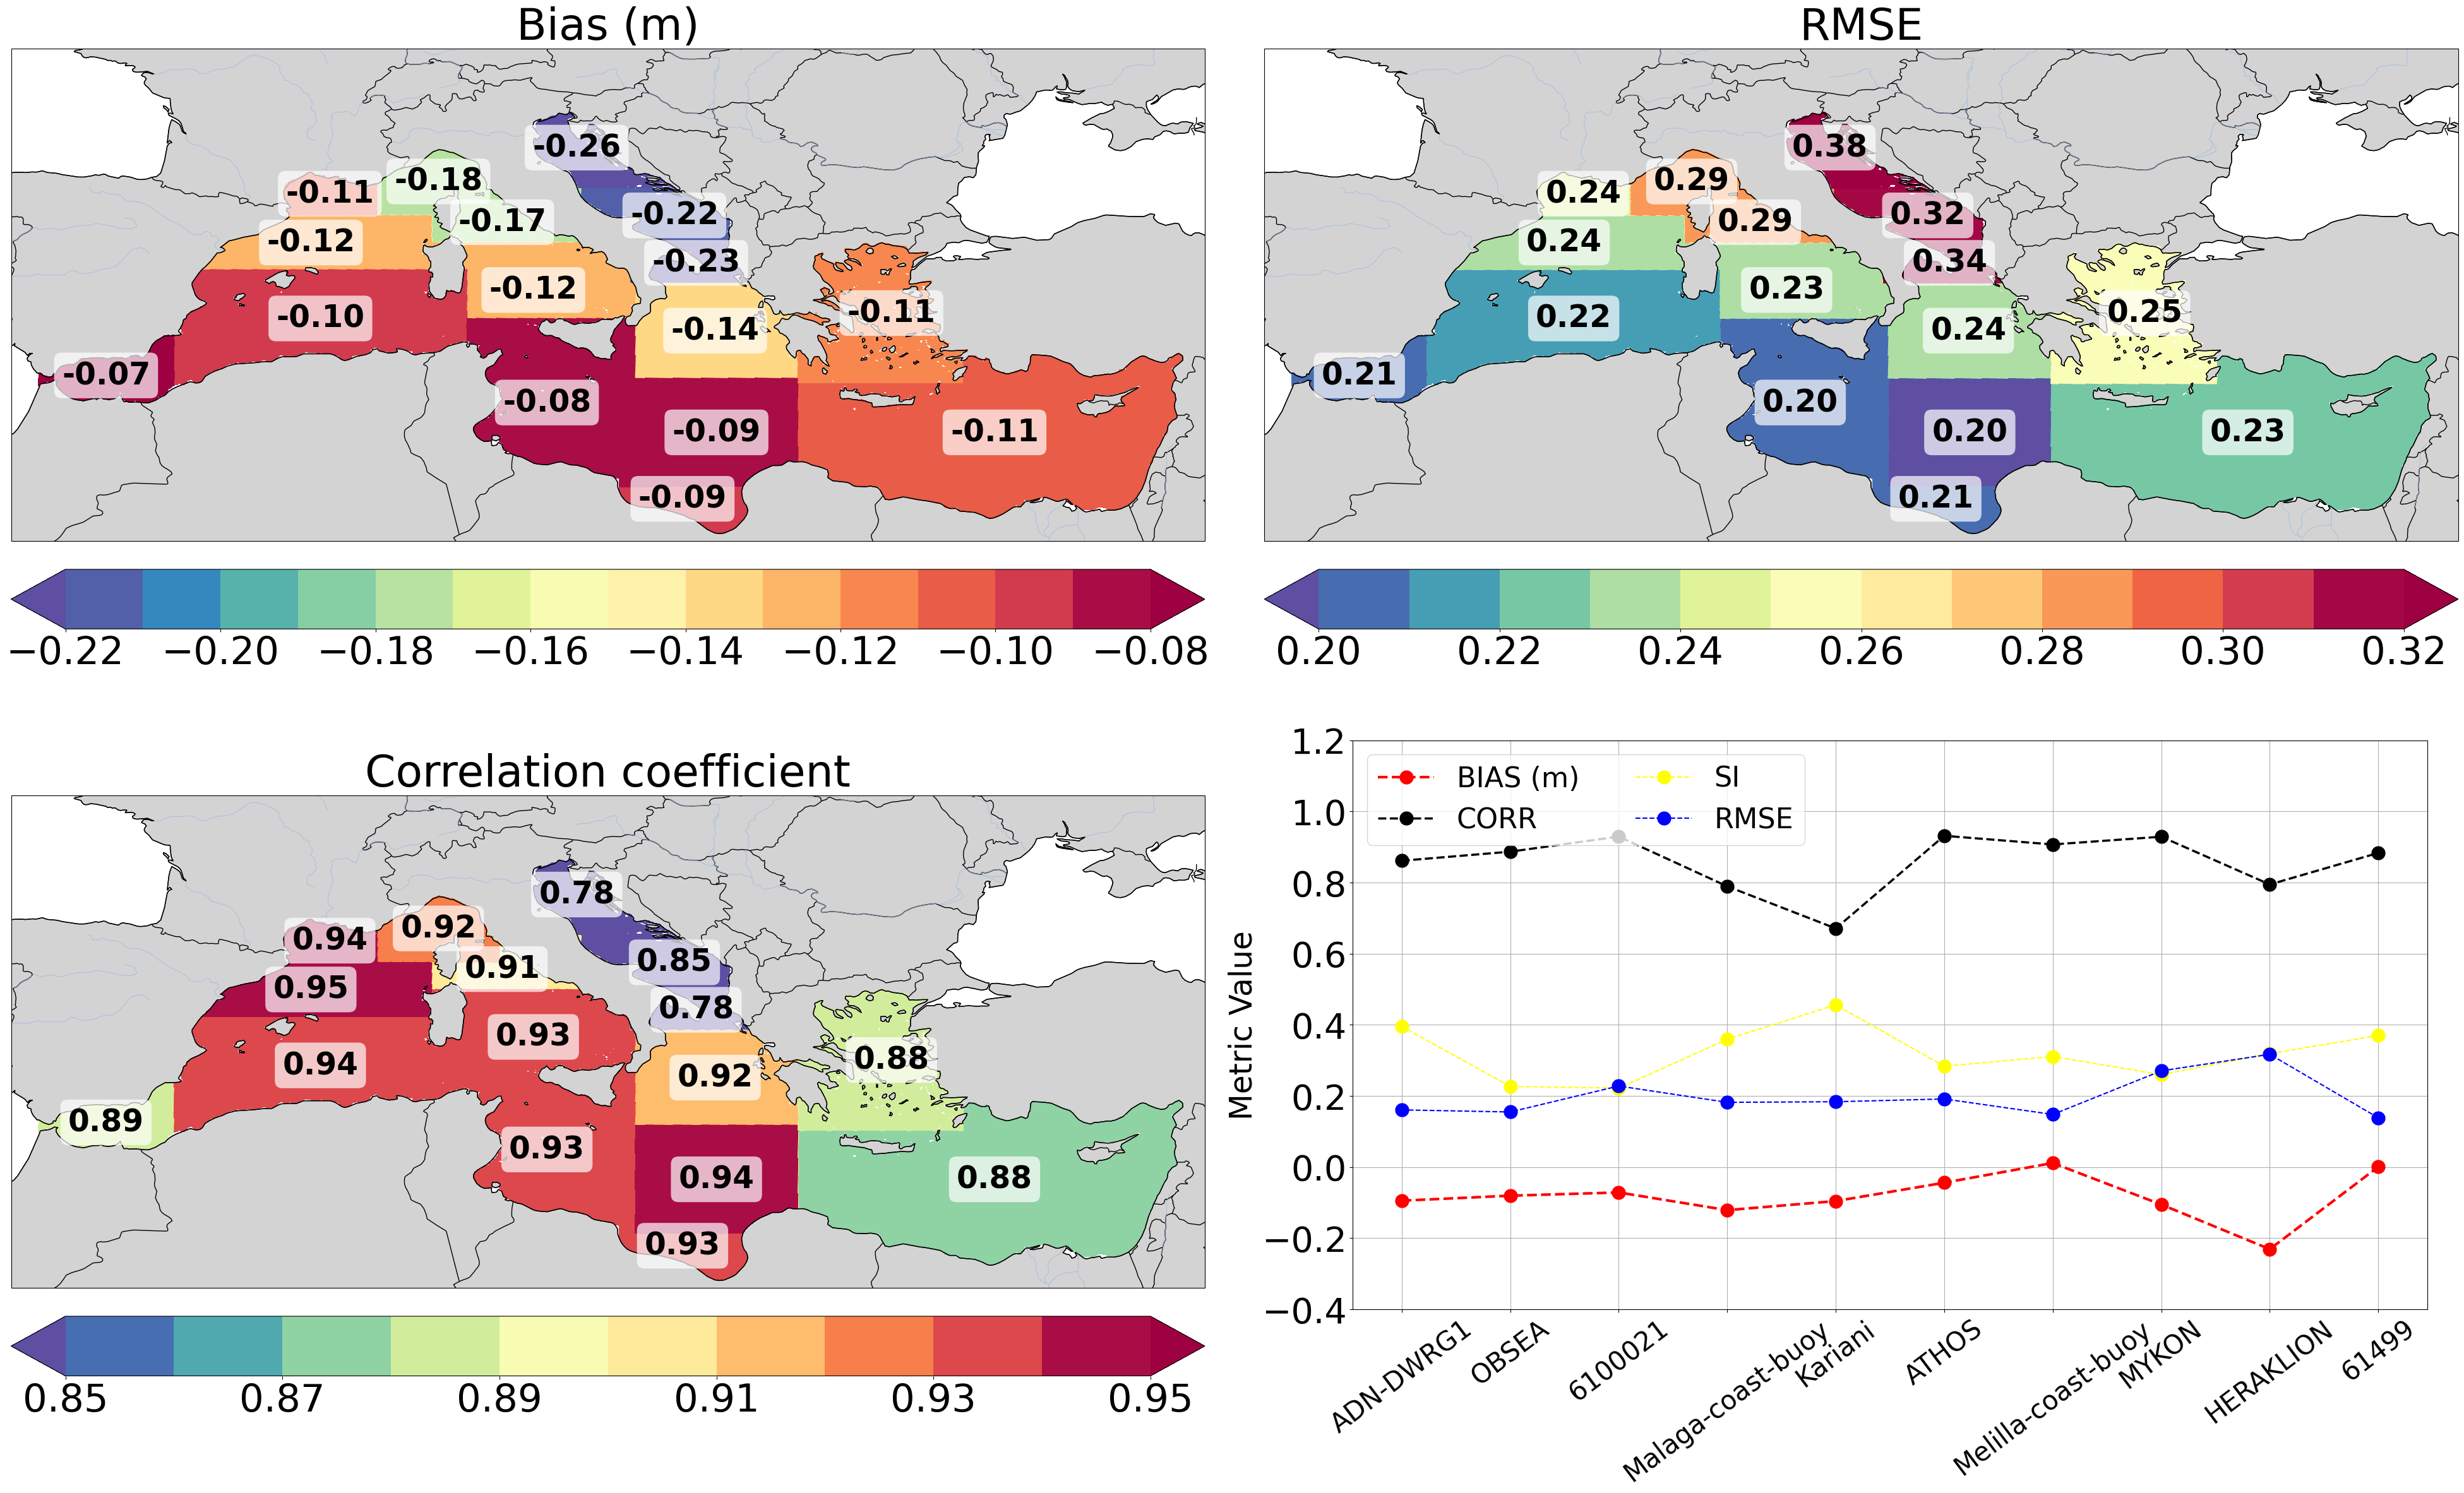

In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(50, 30))
gs = gridspec.GridSpec(2, 2, hspace=0.05, wspace=0.05)

ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
ax4 = fig.add_subplot(gs[1, 1])  # ← NO projection

#fig, axes = plt.subplots(2, 2, figsize=(50, 30), subplot_kw=
#                            {'projection': ccrs.PlateCarree()})
#ax1, ax2, ax3, ax4 = axes.flatten()
axes_list=[ax1,ax2,ax3,ax4]
SHRINK=1.0
plt.subplots_adjust(hspace=0.05,wspace=0.05)  # increase vertical spacing

bounds_bias,_ = adaptive_percentile_range(bias_med)
min_bias, max_bias = bounds_bias
norm_1 = mcolors.Normalize(vmin=min_bias, vmax=max_bias)
levels_1 = np.round(np.linspace(min_bias, max_bias, 51), 
                        2)
levels_1 = np.unique(levels_1)

cf = ax1.contourf(
    bias_med.longitude,
    bias_med.latitude,
    bias_med,
    transform=ccrs.PlateCarree(),
    levels=levels_1,
    norm=norm_1,
    cmap="Spectral_r",
    #cmap="YlGnBu",
    #cmap='RdYlBu',
    #cmap='RdBu',
    extend="both"
)

cbar = fig.colorbar(cf, pad=0.04, ax=ax1, shrink=SHRINK,orientation='horizontal')
#cbar.set_label(label="Bias (m)", size=46, labelpad=20)
cbar.ax.tick_params(labelsize=44)
ax1.set_title("Bias (m)", fontsize=50)
style_axis(ax1)

bounds_bias,_ = adaptive_percentile_range(rmse_med)
min_bias, max_bias = bounds_bias
norm_2 = mcolors.Normalize(vmin=min_bias, vmax=max_bias)
levels_2 = np.round(np.linspace(min_bias, max_bias, 51), 
                        2)
levels_2 = np.unique(levels_2)

cf = ax2.contourf(
    rmse_med.longitude,
    rmse_med.latitude,
    rmse_med,
    transform=ccrs.PlateCarree(),
    levels=levels_2,
    norm=norm_2,
    cmap="Spectral_r",
    #cmap="YlGnBu",
    #cmap='RdYlBu',
    #cmap='RdBu',
    extend="both"
)

cbar = fig.colorbar(cf, pad=0.04, ax=ax2, shrink=SHRINK,orientation='horizontal')
#cbar.set_label(label="RMSE", size=46, labelpad=20)
cbar.ax.tick_params(labelsize=44)
ax2.set_title("RMSE", fontsize=50)
style_axis(ax2, no_left_labels=True)

bounds_bias,_ = adaptive_percentile_range(corr_med)
min_bias, max_bias = bounds_bias
norm_3 = mcolors.Normalize(vmin=min_bias, vmax=max_bias)
levels_3 = np.round(np.linspace(min_bias, max_bias, 51), 
                        2)
levels_3 = np.unique(levels_3)

cf = ax3.contourf(
    corr_med.longitude,
    corr_med.latitude,
    corr_med,
    transform=ccrs.PlateCarree(),
    levels=levels_3,
    norm=norm_3,
    cmap="Spectral_r",
    #cmap="YlGnBu",
    #cmap='RdYlBu',
    #cmap='RdBu',
    extend="both"
)

cbar = fig.colorbar(cf, pad=0.04, ax=ax3, shrink=SHRINK,orientation='horizontal')
#cbar.set_label(label="Correlation coef.", size=46, labelpad=20)
cbar.ax.tick_params(labelsize=44)
ax3.set_title("Correlation coefficient", fontsize=50)
style_axis(ax3)

ax4.plot(Platforms_list, BIAS_buoy, linestyle = 'dashed', marker = 'o', color='red',
         label="BIAS (m)", linewidth=3, markersize=15)

ax4.plot(Platforms_list, CORR_buoy, linestyle = 'dashed', marker = 'o', color='black',
         label="CORR", linewidth=2.5, markersize=15)

ax4.plot(Platforms_list, SI_buoy, linestyle = 'dashed', marker = 'o', color='yellow',
         label="SI", linewidth=1.5, markersize=15)

ax4.plot(Platforms_list, RMSE_buoy, linestyle = 'dashed', marker = 'o', color='blue',
         label="RMSE",  linewidth=1.5, markersize=15)

plt.xticks(rotation=37)

ax4.tick_params(axis='x', labelsize=30)
ax4.tick_params(axis='y', labelsize=40)


ax4.set_ylabel("Metric Value", fontsize=35)
ax4.set_ylim([-0.4, 1.2])
ax4.grid(True)
#plt.legend(bbox_to_anchor=(0, 1), loc='upper left', ncol=2, frameon=True)
ax4.legend(fontsize=32, bbox_to_anchor=(0, 1), loc='upper left', ncol=2, frameon=True)


label_offsets = {
    "Adriatic_1":   {"dlon": -1.9},
    "Adriatic_2":   {"dlon": 0.7},
    "Adriatic_3":   {"dlon": 0.1},
    "Aegean":       {"dlon": 0.4},
    "Ionian":       {"dlon": -0.3},
    "Tyrrhenian_1":   {"dlon": -0.4},
    "Balearic":     {"dlat": 1.0, "dlon": 0.3},
    "Algeria":      {"dlat": 0.7},
    "Alboran":      {"dlat": -0.4},
    "Gulf of Lions":      {"dlat": -0.2},
    "Gulf of Sidra":  {"dlat": 0.3}}

region_list = [region_bias,region_rmse,region_corr,region_si]

for j in range(0,len(axes_list)-1):
    for name, info in region_list[j].items():

            dlon = label_offsets.get(name, {}).get("dlon", 0.0)
            dlat = label_offsets.get(name, {}).get("dlat", 0.0)

            axes_list[j].text(
                info["lon_c"] + dlon,
                info["lat_c"] + dlat,
                f"{info['bias']:.2f}",
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=35,
                fontweight="bold",
                color="black",
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.7
                )
            )

pos = ax4.get_position()

ax4.set_position([
    pos.x0 + 0.028,     # shift right if needed
    pos.y0 + 0.06,     # shift up if needed
    pos.width * 0.9,  # shrink width
    pos.height * 0.8   # shrink height
])

fig.savefig('C://Users//kosta//OneDrive//Desktop//Διπλωματική//AGU//300_dpi.png', dpi=300, bbox_inches='tight')

"""# Define the full path for the file, including the non-existent directory
    output_file = f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Pure analysis//Complex analysis (relative angle & vorticity)//SWH//{Region_saves}//complex_plot_{List_seasons[j]} ({Region_plots}).png"

    # Extract the directory path from the file path
    directory = os.path.dirname(output_file)

    # Create the directory if it does not exist, including any intermediate directories
    if not os.path.exists(directory):
        os.makedirs(directory, exist_ok=True) # exist_ok=True prevents error if dir already exists

    fig.savefig(output_file)"""


Altimeter - Buoys plots (option 2)

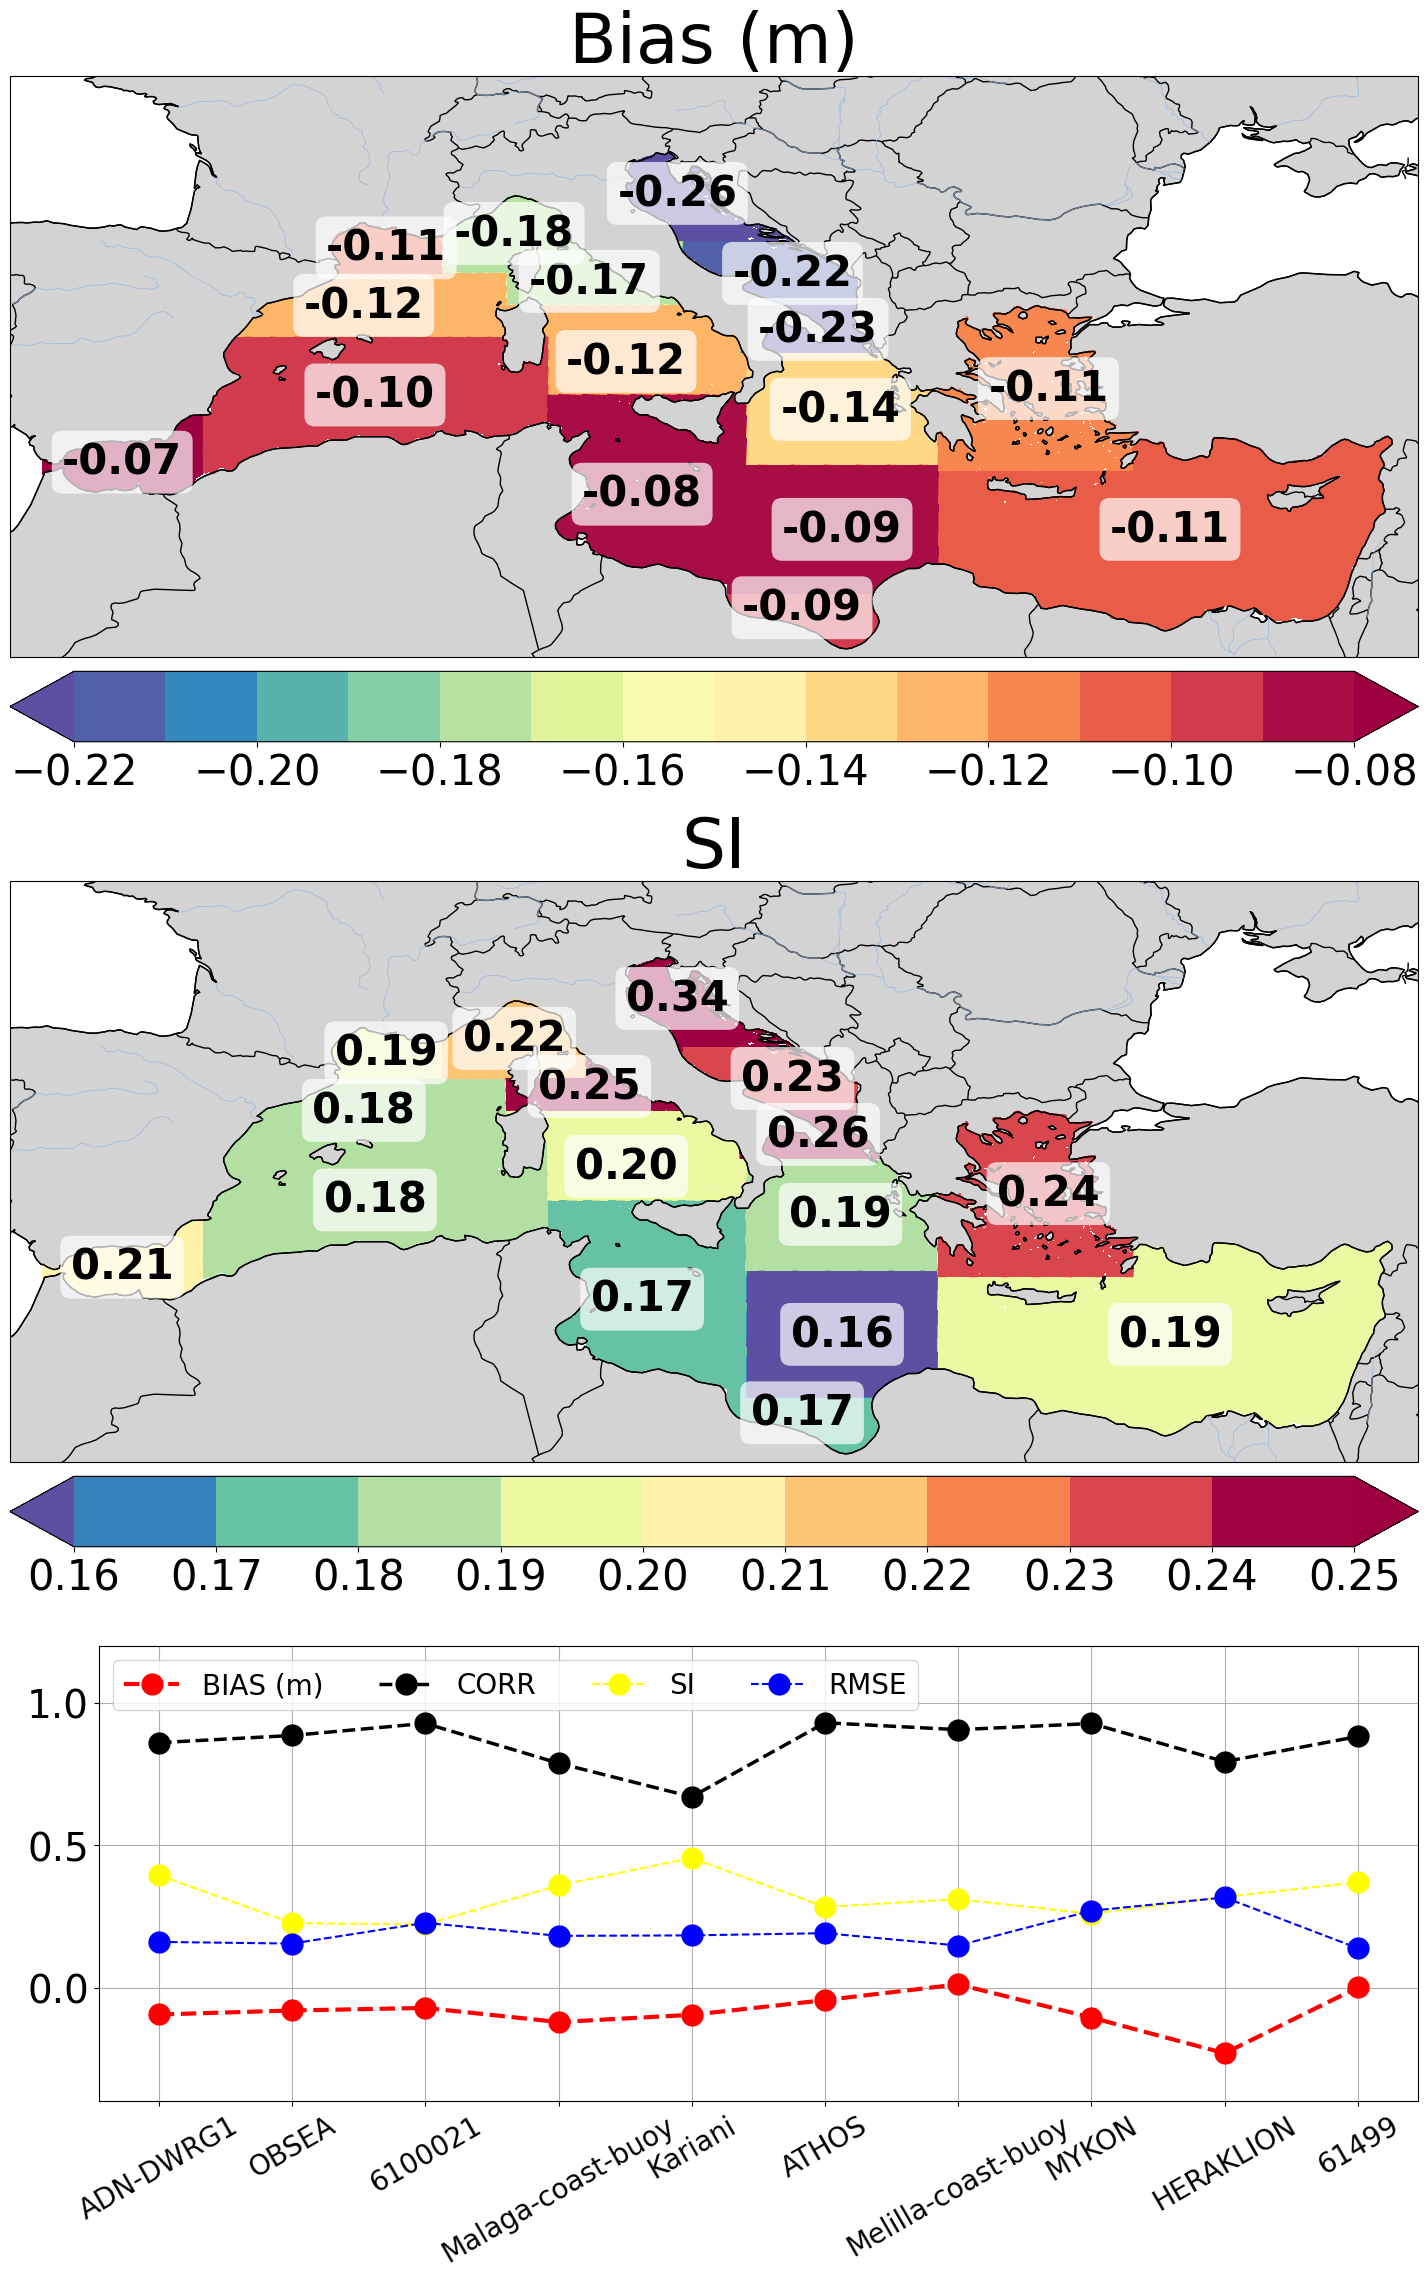

In [31]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(23, 30))
gs = gridspec.GridSpec(3, 1, hspace=0.15)

ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())  # ← NO projection
ax3 = fig.add_subplot(gs[2, 0])  # ← NO projection

axes_list=[ax1,ax2,ax3]
SHRINK=0.79
#plt.subplots_adjust(hspace=2)  # increase vertical spacing

bounds_bias,_ = adaptive_percentile_range(bias_med)
min_bias, max_bias = bounds_bias
norm_1 = mcolors.Normalize(vmin=min_bias, vmax=max_bias)
levels_1 = np.round(np.linspace(min_bias, max_bias, 51), 
                        2)
levels_1 = np.unique(levels_1)

cf = ax1.contourf(
    bias_med.longitude,
    bias_med.latitude,
    bias_med,
    transform=ccrs.PlateCarree(),
    levels=levels_1,
    norm=norm_1,
    cmap="Spectral_r",
    #cmap="YlGnBu",
    #cmap='RdYlBu',
    #cmap='RdBu',
    extend="both"
)

cbar = fig.colorbar(cf, pad=0.02, ax=ax1, shrink=SHRINK,orientation='horizontal')
#cbar.set_label(label="Bias (m)", size=46, labelpad=20)
cbar.ax.tick_params(labelsize=30)
ax1.set_title("Bias (m)", fontsize=50)
style_axis(ax1)

bounds_si,_ = adaptive_percentile_range(si_med)
min_si, max_si = bounds_si
norm_2 = mcolors.Normalize(vmin=min_si, vmax=max_si)
levels_2 = np.round(np.linspace(min_si, max_si, 51), 
                        2)
levels_2 = np.unique(levels_2)

cf = ax2.contourf(
    si_med.longitude,
    si_med.latitude,
    si_med,
    transform=ccrs.PlateCarree(),
    levels=levels_2,
    norm=norm_2,
    cmap="Spectral_r",
    #cmap="YlGnBu",
    #cmap='RdYlBu',
    #cmap='RdBu',
    extend="both"
)

cbar = fig.colorbar(cf, pad=0.02, ax=ax2, shrink=SHRINK,orientation='horizontal')
#cbar.set_label(label="Bias (m)", size=46, labelpad=20)
cbar.ax.tick_params(labelsize=30)
ax2.set_title("SI", fontsize=50)
style_axis(ax2)


ax3.plot(Platforms_list, BIAS_buoy, linestyle = 'dashed', marker = 'o', color='red',
         label="BIAS (m)", linewidth=3, markersize=15)

ax3.plot(Platforms_list, CORR_buoy, linestyle = 'dashed', marker = 'o', color='black',
         label="CORR", linewidth=2.5, markersize=15)

ax3.plot(Platforms_list, SI_buoy, linestyle = 'dashed', marker = 'o', color='yellow',
         label="SI", linewidth=1.5, markersize=15)

ax3.plot(Platforms_list, RMSE_buoy, linestyle = 'dashed', marker = 'o', color='blue',
         label="RMSE",  linewidth=1.5, markersize=15)

plt.xticks(rotation=30)

ax3.tick_params(axis='x', labelsize=20)
ax3.tick_params(axis='y', labelsize=28)


#ax2.set_ylabel("Metric Value", fontsize=35)
ax3.set_ylim([-0.4, 1.2])
ax3.grid(True)
#plt.legend(bbox_to_anchor=(0, 1), loc='upper left', ncol=2, frameon=True)
ax3.legend(fontsize=20, bbox_to_anchor=(0, 1), loc='upper left', ncol=4, 
           frameon=True)


label_offsets = {
    "Adriatic_1":   {"dlon": -1.9},
    "Adriatic_2":   {"dlon": 0.7},
    "Adriatic_3":   {"dlon": 0.1},
    "Aegean":       {"dlon": 0.4},
    "Ionian":       {"dlon": -0.3},
    "Tyrrhenian_1":   {"dlon": -0.4},
    "Balearic":     {"dlat": 1.0, "dlon": 0.3},
    "Algeria":      {"dlat": 0.7},
    "Alboran":      {"dlat": -0.4},
    "Gulf of Lions":      {"dlat": -0.2},
    "Gulf of Sidra":  {"dlat": 0.3}}

region_list = [region_bias,region_si,region_rmse,region_corr]

for j in range(0,len(axes_list)-1):
    for name, info in region_list[j].items():

            dlon = label_offsets.get(name, {}).get("dlon", 0.0)
            dlat = label_offsets.get(name, {}).get("dlat", 0.0)

            axes_list[j].text(
                info["lon_c"] + dlon,
                info["lat_c"] + dlat,
                f"{info['bias']:.2f}",
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=30,
                fontweight="bold",
                color="black",
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.7
                )
            )

# define the position of the 3rd plot

pos = ax3.get_position()

ax3.set_position([
    pos.x0 + 0.12,     # shift right if needed
    pos.y0 + 0.095,     # shift up if needed
    pos.width * 0.74,  # shrink width
    pos.height * 0.65   # shrink height
])

Buoy metrics in each buoy

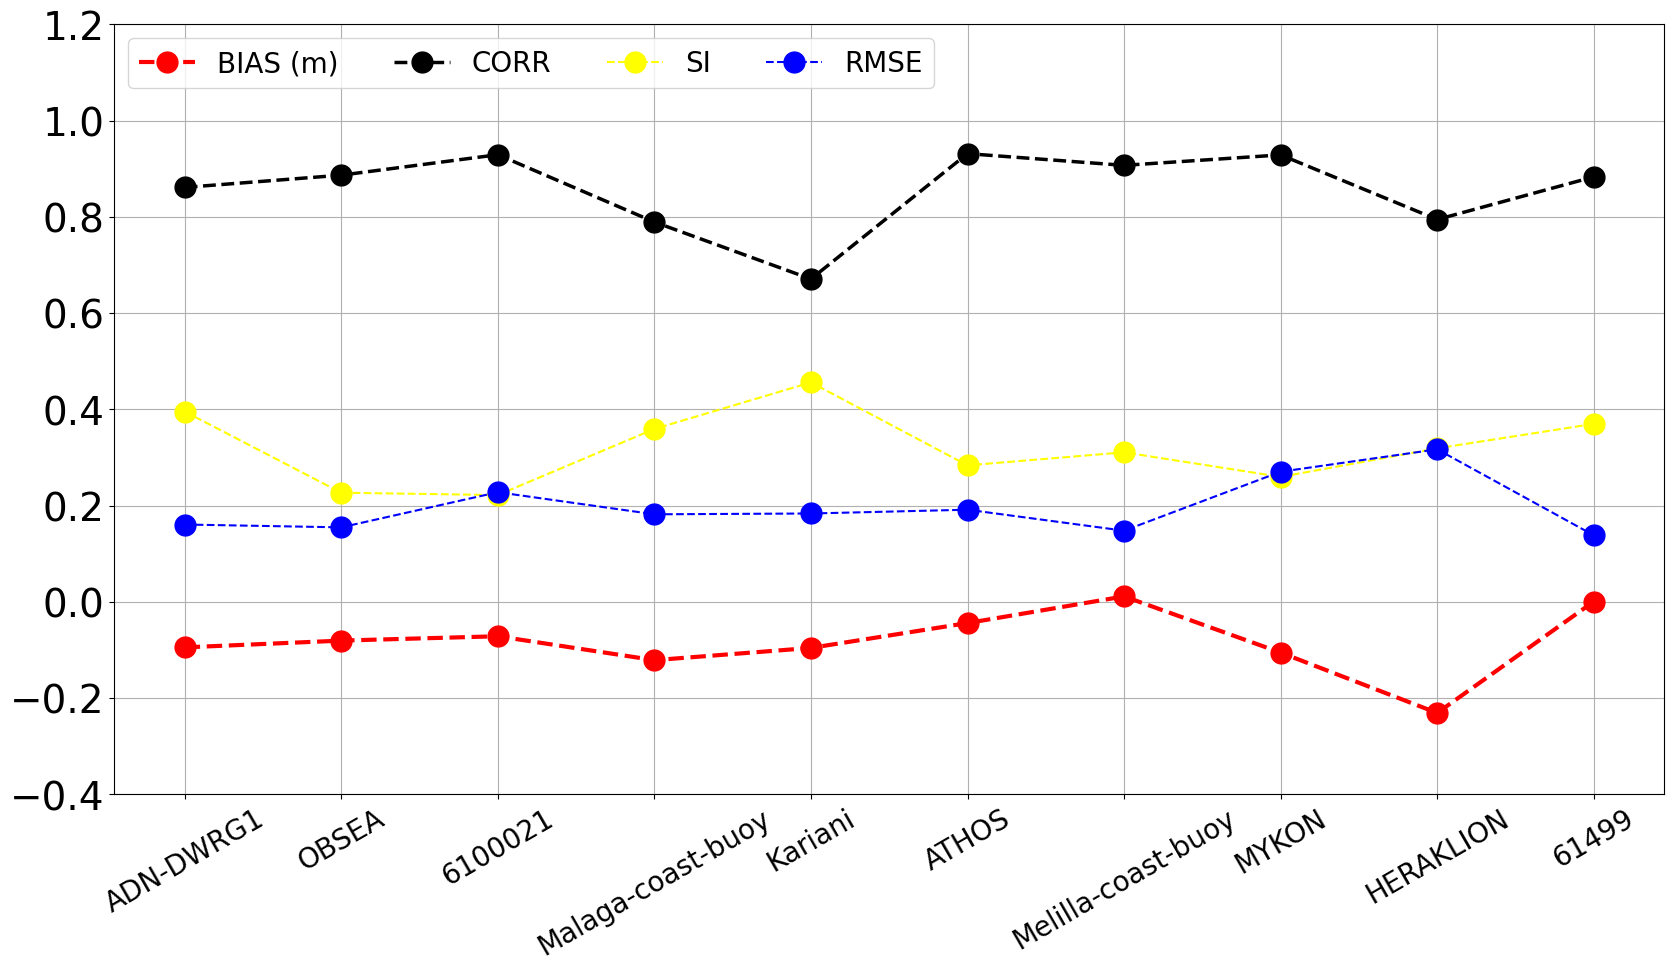

In [ ]:
fig, ax = plt.subplots(figsize=(20,10))

ax.plot(Platforms_list, BIAS_buoy, linestyle = 'dashed', marker = 'o', color='red',
         label="BIAS (m)", linewidth=3, markersize=15)

ax.plot(Platforms_list, CORR_buoy, linestyle = 'dashed', marker = 'o', color='black',
         label="CORR", linewidth=2.5, markersize=15)

ax.plot(Platforms_list, SI_buoy, linestyle = 'dashed', marker = 'o', color='yellow',
         label="SI", linewidth=1.5, markersize=15)

ax.plot(Platforms_list, RMSE_buoy, linestyle = 'dashed', marker = 'o', color='blue',
         label="RMSE",  linewidth=1.5, markersize=15)

plt.xticks(rotation=30)

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=28)

ax.set_ylim([-0.4, 1.2])
ax.grid(True)
ax.legend(fontsize=20, bbox_to_anchor=(0, 1), loc='upper left', ncol=4, 
           frameon=True)